# Step 1: Environment Setup and File Verification

In [1]:
# VERSION CHECK
#
# This checks that all the tools needed are installed.
import sys
import pandas as pd
import numpy as np
import matplotlib
import openpyxl

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("openpyxl:", openpyxl.__version__)

Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:28:27) [Clang 14.0.6 ]
pandas: 2.2.2
numpy: 1.26.4
matplotlib: 3.9.2
openpyxl: 3.1.5


In [2]:
# FILE CHECK AND WORKING DIRECTORY
#
# Standard library imports for file handling and data manipulation.
import os
import pandas as pd

# Set the working directory to the folder containing this notebook.
# This allows all files to be referenced by filename only, making the
# notebook fully portable across different machines.
os.chdir(os.path.dirname(os.path.abspath("thesis_main.ipynb")))

# Define the ten Bloomberg export files required for this analysis.
expected_files = [
    "AEX_Index.xlsx",    "AEX_Metadata.xlsx",
    "CAC_Index.xlsx",    "CAC_Metadata.xlsx",
    "DAX_Index.xlsx",    "DAX_Metadata.xlsx",
    "FTSE_Index.xlsx",   "FTSE_Metadata.xlsx",
    "IBEX_Index.xlsx",   "IBEX_Metadata.xlsx",
]

# Verify all files are present before attempting to load any data.
print("Checking all Bloomberg data files are present:")
print()
all_found = True
for f in expected_files:
    if os.path.exists(f):
        print(f"  YES:  {f}")
    else:
        print(f"  MISSING: {f}")
        all_found = False

print()
if all_found:
    print("All 10 files found. Ready to proceed.")
else:
    print("Some files are missing. Move them into the same folder as this notebook.")

Checking all Bloomberg data files are present:

  YES:  AEX_Index.xlsx
  YES:  AEX_Metadata.xlsx
  YES:  CAC_Index.xlsx
  YES:  CAC_Metadata.xlsx
  YES:  DAX_Index.xlsx
  YES:  DAX_Metadata.xlsx
  YES:  FTSE_Index.xlsx
  YES:  FTSE_Metadata.xlsx
  YES:  IBEX_Index.xlsx
  YES:  IBEX_Metadata.xlsx

All 10 files found. Ready to proceed.


# Step 2: Data Loading and Reshaping

In [3]:
# RESHAPING FUNCTION AND LOADING INDEX FILES
#
def reshape_bloomberg_wide(filepath, sheet_name, country):
    """
    Converts a Bloomberg wide-format Excel export into a long-format
    panel with one row per firm per day.

    filepath   : Excel filename
    sheet_name : sheet to read (varies across files)
    country    : country label to attach to all rows from this file
    """

    # Load without headers to preserve the raw Bloomberg layout.
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)

    # Each security occupies a 9-column block: one date column, seven
    # data fields, and one empty separator. Blocks begin at columns
    # 0, 9, 18, 27, and so on across the sheet.
    BLOCK_SIZE = 9
    all_firms  = []
    n_cols     = raw.shape[1]

    for start_col in range(0, n_cols, BLOCK_SIZE):

        # Row index 4 contains the Bloomberg ticker for this block.
        # An empty cell indicates a non-firm column and is skipped.
        ticker = raw.iloc[4, start_col]
        if pd.isna(ticker):
            continue

        ticker = str(ticker).strip()

        # Row index 5 contains the Bloomberg field codes, used as column headers.
        fields = raw.iloc[5, start_col : start_col + 8].tolist()

        # Daily observations begin at row index 6.
        firm_data = raw.iloc[6:, start_col : start_col + 8].copy()
        firm_data.columns = fields

        # Drop rows with no date entry.
        firm_data = firm_data.dropna(subset=["Dates"])

        # Attach identifiers.
        firm_data["TICKER"]  = ticker
        firm_data["COUNTRY"] = country

        all_firms.append(firm_data)

    return pd.concat(all_firms, ignore_index=True)


# Apply the reshape function to each index file with its correct sheet name.
print("Loading and reshaping all five index files...")
print("This may take 20-30 seconds.")
print()

aex  = reshape_bloomberg_wide("AEX_Index.xlsx",  "Worksheet", "NETHERLANDS")
cac  = reshape_bloomberg_wide("CAC_Index.xlsx",  "Worksheet", "FRANCE")
dax  = reshape_bloomberg_wide("DAX_Index.xlsx",  "Worksheet", "GERMANY")
ftse = reshape_bloomberg_wide("FTSE_Index.xlsx", "Sheet1",    "ITALY")
ibex = reshape_bloomberg_wide("IBEX_Index.xlsx", "Worksheet", "SPAIN")

# Concatenate all five country panels into a single master panel.
panel = pd.concat([aex, cac, dax, ftse, ibex], ignore_index=True)

# Note on the return field: DAY_TO_DAY_TOT_RETURN_GROSS_DVDS is expressed
# in percentage terms (e.g. 1.47 means +1.47%). When constructing the
# return variable in the variable construction cells below, this field
# must be divided by 100 to convert it to decimal form before use in
# any calculation.

print("Shape of combined panel (rows, columns):", panel.shape)
print()
print("Column names:", panel.columns.tolist())
print()
print("First 3 rows:")
print(panel.head(3).to_string())

Loading and reshaping all five index files...
This may take 20-30 seconds.

Shape of combined panel (rows, columns): (36890, 10)

Column names: ['Dates', 'PX_LAST', 'PX_VOLUME', 'CUR_MKT_CAP', 'PX_OPEN', 'PX_HIGH', 'PX_LOW', 'DAY_TO_DAY_TOT_RETURN_GROSS_DVDS', 'TICKER', 'COUNTRY']

First 3 rows:
                 Dates PX_LAST PX_VOLUME CUR_MKT_CAP PX_OPEN PX_HIGH PX_LOW DAY_TO_DAY_TOT_RETURN_GROSS_DVDS          TICKER      COUNTRY
0  2019-11-01 00:00:00   36.59    310195   4046.1259   36.15   36.61  36.01                           1.4698  AALB NA Equity  NETHERLANDS
1  2019-11-04 00:00:00   37.22    285468   4115.7914   36.67   37.28  36.64                           1.7218  AALB NA Equity  NETHERLANDS
2  2019-11-05 00:00:00   38.16    418512   4219.7367   37.02   38.16  36.95                           2.5255  AALB NA Equity  NETHERLANDS


In [4]:
# SANITY CHECK
#
# Verify that the reshaped panel matches the expected sample structure.
#
# Note: after all exclusions the final sample is 164 firms and
# 35,588 firm-day observations. Exclusions are: MT NA Equity and
# URW NA Equity deduplicated from France to Netherlands; STMPA FP
# Equity deduplicated from Italy to France; CNH US Equity and STLA
# US Equity removed on data quality grounds; WDI GY Equity (Wirecard)
# removed on analytical grounds. See cells below for full details.

print("Unique firms (tickers):", panel["TICKER"].nunique())
print()

print("Firms per country:")
print(panel.groupby("COUNTRY")["TICKER"].nunique())
print()

print("Earliest date:", panel["Dates"].min())
print("Latest date:  ", panel["Dates"].max())

Unique firms (tickers): 167

Firms per country:
COUNTRY
FRANCE         40
GERMANY        30
ITALY          40
NETHERLANDS    25
SPAIN          35
Name: TICKER, dtype: int64

Earliest date: 2019-11-01 00:00:00
Latest date:   2020-08-31 00:00:00


# Step 3: Sample Deduplication and Exclusions

In [5]:
# INDEX FILE DEDUPLICATION
#
# Three tickers appear in two index files due to cross-listings and are
# deduplicated by retaining the primary listing entry only.
#
# Cross-listing deduplication decisions:
#   MT NA Equity    → NETHERLANDS (control). Duplicate under FRANCE dropped.
#                     Retaining the correct Netherlands entry is material:
#                     had the France duplicate been kept instead, this firm
#                     would have been incorrectly coded as treated.
#   URW NA Equity   → NETHERLANDS (control). Duplicate under FRANCE dropped.
#                     Same materiality applies as for MT NA Equity.
#   STMPA FP Equity → FRANCE (treated). Duplicate under ITALY dropped.
#                     Both France and Italy are treated countries, so this
#                     reassignment has no bearing on treatment coding.
#
# Note on FTSE MIB data collection: Bloomberg restricts programmatic access
# to FTSE MIB constituent data due to index provider licensing restrictions
# (confirmed via Bloomberg Help Desk, reference H#1323389042). The Italian
# constituent list was therefore compiled manually from the official Borsa
# Italiana website, using the published FTSE MIB composition as of
# 23 March 2020. This date was selected as it falls within the ban window
# and reflects the index composition relevant to the analysis period.
# Price and volume data for the identified constituents were subsequently
# extracted from Bloomberg in the standard way.
# 
# Two additional FTSE MIB constituents are removed on data quality grounds:
#
#   CNH US Equity  (CNH Industrial): Primary listing is on the NYSE. The
#   Bloomberg data for this ticker reflects US market trading in USD, not
#   Italian market trading. Including it would introduce measurement error
#   into the European market quality outcomes this thesis estimates.
#
#   STLA US Equity (Stellantis): Stellantis was formed on 16 January 2021
#   from the merger of Fiat Chrysler Automobiles and PSA Group. The firm
#   did not exist during the sample period (November 2019 to August 2020).
#   Any Bloomberg data exported under this ticker for that period is
#   reconstructed or backdated and cannot be treated as reliable.
#
# Final sample after all exclusions:
#   France: 38 firms (treated)      ← 40 minus MT NA Equity and URW NA Equity
#                                     (both retained under Netherlands)
#   Italy: 37 firms (treated)       ← 40 minus STMPA FP Equity (retained under
#                                     France), CNH US Equity, and STLA US Equity
#   Spain: 35 firms (treated)       ← no exclusions
#   Germany: 30 firms (control)     ← no exclusions
#   Netherlands: 25 firms (control) ← no exclusions; MT NA Equity and URW NA
#                                     Equity are retained here, not added
#   
# Total after this cell: 165 firms, approximately 35,805 firm-day observations.
# Further exclusions based on the data validation diagnostic are applied
# in Step 5 below.

# Step 1: Remove cross-listed duplicates.
duplicates_to_drop = {
    "MT NA Equity":    "FRANCE",
    "STMPA FP Equity": "ITALY",
    "URW NA Equity":   "FRANCE",
}

rows_before = len(panel)

for ticker, country_to_drop in duplicates_to_drop.items():
    mask = (panel["TICKER"] == ticker) & (panel["COUNTRY"] == country_to_drop)
    panel = panel[~mask]

# Step 2: Remove US-primary-listed FTSE MIB constituents.
us_listed_to_drop = ["CNH US Equity", "STLA US Equity"]
panel = panel[~panel["TICKER"].isin(us_listed_to_drop)]

panel = panel.reset_index(drop=True)

rows_after = len(panel)

print(f"Rows before all exclusions: {rows_before}")
print(f"Rows removed:               {rows_before - rows_after}")
print(f"Rows after all exclusions:  {rows_after}")
print()
print(f"Unique firms: {panel['TICKER'].nunique()}")
print()
print("Firms per country:")
print(panel.groupby("COUNTRY")["TICKER"].nunique())

Rows before all exclusions: 36890
Rows removed:               1085
Rows after all exclusions:  35805

Unique firms: 165

Firms per country:
COUNTRY
FRANCE         38
GERMANY        30
ITALY          37
NETHERLANDS    25
SPAIN          35
Name: TICKER, dtype: int64


# Step 4: Data Validation Checks and Outlier Diagnostic

In [6]:
# RENAME AND PARSE THE DATE COLUMN
#
# Rename the date column to a clean standard name and ensure it is
# stored as a proper date type, not a datetime with a time component.
# This is required for all subsequent date-based operations.

panel = panel.rename(columns={"Dates": "DATE"})
panel["DATE"] = pd.to_datetime(panel["DATE"]).dt.normalize()

print("Date column type:", panel["DATE"].dtype)
print("Sample dates:")
print(panel["DATE"].head(5).tolist())

Date column type: datetime64[ns]
Sample dates:
[Timestamp('2019-11-01 00:00:00'), Timestamp('2019-11-04 00:00:00'), Timestamp('2019-11-05 00:00:00'), Timestamp('2019-11-06 00:00:00'), Timestamp('2019-11-07 00:00:00')]


In [7]:
# CHECK FOR DUPLICATE FIRM-DATE ROWS
#
# Each firm should appear exactly once per trading day.
# Duplicate firm-date combinations would corrupt all subsequent calculations.

n_duplicates = panel.duplicated(subset=["TICKER", "DATE"]).sum()
print("Duplicate firm-date rows:", n_duplicates)

if n_duplicates == 0:
    print("No duplicates found. Panel structure is clean.")
else:
    print("Duplicates detected. Inspect before continuing.")
    print(panel[panel.duplicated(subset=["TICKER", "DATE"], keep=False)]
          [["DATE", "TICKER", "COUNTRY"]].head(10).to_string())

Duplicate firm-date rows: 0
No duplicates found. Panel structure is clean.


In [8]:
# CHECK FOR MISSING KEY IDENTIFIERS
#
# Verify that no rows are missing a firm identifier, date, or country label.
# Missing identifiers would make rows unassignable to any firm or period.
# NAME and ID_ISIN are checked later after the metadata merge in Step 6.

print("Missing values in key identifier columns:")
print(panel[["DATE", "TICKER", "COUNTRY"]].isna().sum())

Missing values in key identifier columns:
DATE       0
TICKER     0
COUNTRY    0
dtype: int64


In [9]:
# CHECK DATE COVERAGE AND FIRM COUNTS
#
# Confirm the date range and trading day count.
# Verify firm counts by country match the final sample structure.

print("Date range:")
print("  Earliest:", panel["DATE"].min().date())
print("  Latest:  ", panel["DATE"].max().date())
print()

trading_days = panel["DATE"].nunique()
print("Total unique trading days:", trading_days)
print()

print("Firms per country:")
print(panel.groupby("COUNTRY")["TICKER"].nunique())
print()

print("Total unique firms:", panel["TICKER"].nunique())
print("Total firm-day observations:", len(panel))

Date range:
  Earliest: 2019-11-01
  Latest:   2020-08-31

Total unique trading days: 217

Firms per country:
COUNTRY
FRANCE         38
GERMANY        30
ITALY          37
NETHERLANDS    25
SPAIN          35
Name: TICKER, dtype: int64

Total unique firms: 165
Total firm-day observations: 35805


In [10]:
# CHECK FOR MISSING PRICES AND ZERO VOLUMES
#
# Assess the extent of missing values in the core data fields.
# Some missing values are acceptable due to non-trading days or
# suspensions, but systematic gaps indicate a data problem.

print("Missing values in core data fields:")
core_fields = ["PX_LAST", "PX_VOLUME", "CUR_MKT_CAP",
               "PX_HIGH", "PX_LOW", "DAY_TO_DAY_TOT_RETURN_GROSS_DVDS"]
print(panel[core_fields].isna().sum())
print()

# Check for zero or negative volumes, which would break the log transformation
# and the Amihud illiquidity calculation.
zero_vol = (panel["PX_VOLUME"] <= 0).sum()
print("Zero or negative volume rows:", zero_vol)
print()

# Check for zero or negative prices.
zero_price = (panel["PX_LAST"] <= 0).sum()
print("Zero or negative price rows:", zero_price)

Missing values in core data fields:
PX_LAST                             0
PX_VOLUME                           0
CUR_MKT_CAP                         0
PX_HIGH                             0
PX_LOW                              0
DAY_TO_DAY_TOT_RETURN_GROSS_DVDS    0
dtype: int64

Zero or negative volume rows: 0

Zero or negative price rows: 0


In [11]:
# CHECK FOR CONSTANT PRICE SERIES
#
# A firm with a completely constant price series over time would indicate
# a data extraction error or a suspended security.
# Flag any firm whose closing price never changes across the full sample.

price_std = panel.groupby("TICKER")["PX_LAST"].std()
constant_series = price_std[price_std == 0]

print("Firms with constant price series:", len(constant_series))
if len(constant_series) > 0:
    print(constant_series)
else:
    print("No constant price series detected.")

Firms with constant price series: 0
No constant price series detected.


In [12]:
# EARLY RET CONSTRUCTION
#
# RET is constructed here ahead of the full variable construction step
# solely to enable the outlier diagnostic below. The return field is
# divided by 100 to convert from percentage to decimal form.
# Full variable construction including LOG_VOLUME, Amihud illiquidity,
# and rolling volatility takes place in Step 7.

panel["RET"] = pd.to_numeric(
    panel["DAY_TO_DAY_TOT_RETURN_GROSS_DVDS"], errors="coerce") / 100

print("RET successfully constructed.")
print("Missing RET values:", panel["RET"].isna().sum())
print("Sample values:")
print(panel["RET"].head(5).tolist())

RET successfully constructed.
Missing RET values: 0
Sample values:
[0.014698, 0.017218, 0.025255, 0.001572, 0.022501000000000004]


In [13]:
# OUTLIER DIAGNOSTIC
#
# Comprehensive outlier and data quality diagnostic across all 165 firms.
# Results inform the exclusion decisions applied in Step 5.
# Each flagged finding is assessed individually below.

# 1. Firms with extreme single-day returns beyond +/- 50%.
extreme_rets = panel[panel["RET"].abs() > 0.50]
print("=== Firms with single-day returns exceeding +/-50% ===")
print(extreme_rets.groupby("TICKER")[["RET"]].agg(["min", "max", "count"]))
print()

# 2. Firms with any single-day return beyond +/- 25%.
large_rets = panel[panel["RET"].abs() > 0.25]
print("=== Firms with single-day returns exceeding +/-25% ===")
print(large_rets.groupby("TICKER")[["RET"]].agg(["min", "max", "count"]))
print()

# 3. Firms with unusually low average volume relative to the sample.
# Very low volume firms may have been suspended or illiquid throughout.
avg_vol = panel.groupby("TICKER")["PX_VOLUME"].mean().sort_values()
print("=== 10 lowest average volume firms ===")
print(avg_vol.head(10))
print()

# 4. Firms with missing return values after numeric conversion.
missing_ret = panel.groupby("TICKER")["RET"].apply(lambda x: x.isna().sum())
missing_ret = missing_ret[missing_ret > 0]
print("=== Firms with missing return values ===")
if len(missing_ret) > 0:
    print(missing_ret)
else:
    print("None")
print()

# 5. Firms with zero volume on more than 5 days.
zero_vol_days = panel[panel["PX_VOLUME"] == 0].groupby("TICKER").size()
zero_vol_days = zero_vol_days[zero_vol_days > 5]
print("=== Firms with zero volume on more than 5 days ===")
if len(zero_vol_days) > 0:
    print(zero_vol_days)
else:
    print("None")
print()

# 6. Firms whose price dropped by more than 80% over the full sample period.
# This may indicate delisting, suspension, or fraud beyond Wirecard.
first_price = panel.groupby("TICKER")["PX_LAST"].first()
last_price  = panel.groupby("TICKER")["PX_LAST"].last()
price_change = (last_price - first_price) / first_price
large_drops = price_change[price_change < -0.80].sort_values()
print("=== Firms with total price decline exceeding 80% over sample ===")
if len(large_drops) > 0:
    print(large_drops.round(4))
else:
    print("None")
print()

# Summary of diagnostic findings:
# - WDI GY Equity (Wirecard): flagged across checks 1, 2, and 6. Excluded
#   in Step 5. See Step 5 for full justification.
# - ATL, FTI, IAG, MBG, MEL: single-day returns above 25% reflect genuine
#   COVID-period market stress. Retained.
# - ATO FP Equity: low share count explained by high share price (~5,100 EUR).
#   Daily EUR turnover (~30m EUR) is normal for a CAC 40 constituent.
#   The Amihud measure uses price x volume in EUR, resolving any apparent
#   anomaly. Retained.
# - No missing returns, no zero-volume firms, no other price collapses found.

=== Firms with single-day returns exceeding +/-50% ===
                    RET                
                    min       max count
TICKER                                 
WDI GY Equity -0.712811  1.544887     5

=== Firms with single-day returns exceeding +/-25% ===
                    RET                
                    min       max count
TICKER                                 
ATL IM Equity  0.266492  0.266492     1
FTI FP Equity  0.317833  0.317833     1
IAG SM Equity -0.279017 -0.279017     1
MBG GY Equity  0.272767  0.272767     1
MEL SM Equity  0.259724  0.265823     2
WDI GY Equity -0.712811  1.544887    11

=== 10 lowest average volume firms ===
TICKER
ATO FP Equity        6259.898618
RMS FP Equity       67790.184332
VIS SM Equity      108664.709677
ADYEN NA Equity    116410.004608
ANA SM Equity      122649.562212
IMCD NA Equity     170052.497696
KER FP Equity      237378.087558
DIA IM Equity       272173.81106
CIE SM Equity      307693.700461
SW FP Equity       396604

# Step 5: Final Sample Exclusions

In [14]:
# WIRECARD REMOVAL
#
# Wirecard AG (WDI GY Equity) is removed from the baseline sample.
# Its June 2020 extreme returns (-71% to +154%) and near-total price
# collapse (-99.5% over the sample) are attributable to the disclosure
# of a large-scale accounting fraud, not to market dynamics related to
# the short-selling ban or COVID-19. Retaining this firm would bias
# control-group volatility and volume estimates in the post-ban period
# in a manner unrelated to the research question.
#
# Wirecard is a DAX constituent assigned to the control group (Germany).
# Its exclusion reduces the sample to 164 firms and approximately 35,588
# firm-day observations. Results are robust to its inclusion, as
# demonstrated in the robustness checks.
#
# All other firms flagged in the diagnostic are retained:
# - ATL, FTI, IAG, MBG, MEL: single-day returns above 25% reflect
#   genuine COVID-period market stress, not data errors.
# - ATO FP Equity: low share count is explained by a high share price
#   (~5,100 EUR). Daily EUR turnover (~30m EUR) is normal for a CAC 40
#   constituent. The Amihud measure will use EUR trading value
#   (price x volume) rather than raw share count, which resolves any
#   apparent anomaly.

rows_before = len(panel)

panel = panel[panel["TICKER"] != "WDI GY Equity"].reset_index(drop=True)

rows_after = len(panel)

print(f"Rows before Wirecard removal: {rows_before}")
print(f"Rows removed:                 {rows_before - rows_after}")
print(f"Rows after removal:           {rows_after}")
print()
print(f"Unique firms: {panel['TICKER'].nunique()}")
print()
print("Firms per country:")
print(panel.groupby("COUNTRY")["TICKER"].nunique())

Rows before Wirecard removal: 35805
Rows removed:                 217
Rows after removal:           35588

Unique firms: 164

Firms per country:
COUNTRY
FRANCE         38
GERMANY        29
ITALY          37
NETHERLANDS    25
SPAIN          35
Name: TICKER, dtype: int64


# Step 6: Metadata Loading and Deduplication

In [15]:
# LOADING METADATA FILES
#
# Load all five metadata files and combine them into a single reference table.
# Each Bloomberg metadata export contains two decorative header rows followed
# by Bloomberg field codes in row index 2. Firm data begins at row index 3.

def load_metadata(filepath, sheet_name):
    """
    Loads a Bloomberg metadata export and returns a clean DataFrame
    with Bloomberg field codes as column headers.

    filepath   : Excel filename
    sheet_name : sheet to read (varies across files)
    """
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)

    # Row index 2 contains Bloomberg field codes used as column headers.
    headers = raw.iloc[2, :].tolist()

    # Firm data begins at row index 3.
    data = raw.iloc[3:, :].copy()
    data.columns = headers

    # The first column contains the Bloomberg ticker.
    data = data.rename(columns={data.columns[0]: "TICKER"})
    data = data.dropna(subset=["TICKER"])

    return data.reset_index(drop=True)


meta_aex  = load_metadata("AEX_Metadata.xlsx",  "Worksheet")
meta_cac  = load_metadata("CAC_Metadata.xlsx",  "Worksheet")
meta_dax  = load_metadata("DAX_Metadata.xlsx",  "Worksheet")
meta_ftse = load_metadata("FTSE_Metadata.xlsx", "Sheet1")
meta_ibex = load_metadata("IBEX_Metadata.xlsx", "Worksheet")

# Stack all five metadata tables into one reference table.
metadata = pd.concat([meta_aex, meta_cac, meta_dax, meta_ftse, meta_ibex],
                     ignore_index=True)

print("Metadata shape:", metadata.shape)
print()
print("Columns:", metadata.columns.tolist())
print()
print("First 4 rows:")
print(metadata.head(4).to_string())

Metadata shape: (170, 7)

Columns: ['TICKER', 'NAME', 'ID_ISIN', 'GICS_SECTOR_NAME', 'GICS_INDUSTRY_NAME', 'COUNTRY_FULL_NAME', 'CRNCY']

First 4 rows:
            TICKER                          NAME       ID_ISIN  GICS_SECTOR_NAME             GICS_INDUSTRY_NAME COUNTRY_FULL_NAME CRNCY
0   AALB NA Equity                   AALBERTS NV  NL0000852564       Industrials                      Machinery       NETHERLANDS   EUR
1    ABN NA Equity          ABN AMRO BANK NV-CVA  NL0011540547        Financials                          Banks       NETHERLANDS   EUR
2     AD NA Equity  KONINKLIJKE AHOLD DELHAIZE N  NL0011794037  Consumer Staples  Consumer Staples Distribution       NETHERLANDS   EUR
3  ADYEN NA Equity                      ADYEN NV  NL0012969182        Financials             Financial Services       NETHERLANDS   EUR


In [16]:
# METADATA FILE DEDUPLICATION
#
# Deduplicate the metadata table so that each firm has exactly one row.
# Bloomberg metadata COUNTRY_FULL_NAME reflects country of corporate
# incorporation, not exchange listing, and therefore cannot be used to
# identify which index file a duplicate originated from.
# Since the panel already carries the correct exchange country from the
# reshaping step, metadata deduplication simply retains the first
# occurrence of each ticker.
#
# The following firms are also removed from the metadata, consistent
# with the exclusions applied to the panel in the deduplication cells above:
#
#   CNH US Equity  (CNH Industrial): primary listing NYSE, data reflects
#                  US market trading in USD rather than Italian market trading.
#   STLA US Equity (Stellantis): firm did not exist during the sample period,
#                  having been formed on 16 January 2021.
#   WDI GY Equity  (Wirecard): removed on analytical grounds due to
#                  idiosyncratic fraud-driven collapse in June 2020,
#                  unrelated to the research question.
#
# After all exclusions the metadata table should contain exactly 164 firms,
# consistent with the final analysis sample.

metadata = metadata[~metadata["TICKER"].isin([
    "CNH US Equity",
    "STLA US Equity",
    "WDI GY Equity"
])]

metadata = metadata.drop_duplicates(subset="TICKER", keep="first")
metadata = metadata.reset_index(drop=True)

print("Metadata rows after all exclusions:", len(metadata))
print("Unique tickers:", metadata["TICKER"].nunique())
print()

# Verify the three previously problematic cross-listed tickers are present.
for ticker in ["MT NA Equity", "STMPA FP Equity", "URW NA Equity"]:
    subset = metadata[metadata["TICKER"] == ticker]
    print(f"{ticker}: {len(subset)} row(s)")

Metadata rows after all exclusions: 164
Unique tickers: 164

MT NA Equity: 1 row(s)
STMPA FP Equity: 1 row(s)
URW NA Equity: 1 row(s)


# Step 7: Panel Merge and Metadata Validation

In [17]:
# MERGE METADATA INTO THE PANEL
#
# Merge firm-level metadata into the daily panel on the TICKER column.
# A left join retains all panel rows. Any firm present in the panel but
# absent from the metadata will appear as NaN and is flagged below.
# The expected result is zero unmatched rows and a panel shape of
# (35588, 17) after the merge.

panel = panel.merge(metadata, on="TICKER", how="left")

print("Panel shape after merge:", panel.shape)
print()

missing_meta = panel[panel["NAME"].isna()]
print("Rows with no metadata match:", len(missing_meta))

if len(missing_meta) > 0:
    print("Affected tickers:")
    print(missing_meta["TICKER"].unique())
else:
    print("All firms matched successfully.")

print()
print("Sample rows after merge:")
print(panel[["DATE", "TICKER", "NAME", "COUNTRY",
             "GICS_SECTOR_NAME", "ID_ISIN"]].head(3).to_string())

Panel shape after merge: (35588, 17)

Rows with no metadata match: 0
All firms matched successfully.

Sample rows after merge:
        DATE          TICKER         NAME      COUNTRY GICS_SECTOR_NAME       ID_ISIN
0 2019-11-01  AALB NA Equity  AALBERTS NV  NETHERLANDS      Industrials  NL0000852564
1 2019-11-04  AALB NA Equity  AALBERTS NV  NETHERLANDS      Industrials  NL0000852564
2 2019-11-05  AALB NA Equity  AALBERTS NV  NETHERLANDS      Industrials  NL0000852564


In [18]:
# POST-MERGE VALIDATION
#
# Confirm that the metadata merge introduced no missing values in the
# firm-level identifier columns.

print("Missing values in metadata columns after merge:")
print(panel[["NAME", "ID_ISIN", "GICS_SECTOR_NAME"]].isna().sum())

Missing values in metadata columns after merge:
NAME                0
ID_ISIN             0
GICS_SECTOR_NAME    0
dtype: int64


In [19]:
# CURRENCY VERIFICATION CHECK
#
# Verify that all firms in the sample are denominated in EUR.
# The Amihud illiquidity measure uses price multiplied by volume to
# compute daily trading value in monetary terms. If any firm trades
# in a different currency, its trading value would not be comparable
# to EUR-denominated firms without applying an exchange rate adjustment.
# All five indices in this sample are EUR-denominated, but this is
# verified explicitly rather than assumed.

print("Currency distribution across all firms:")
print(panel.groupby("CRNCY")["TICKER"].nunique())
print()

non_eur = panel[panel["CRNCY"] != "EUR"]
print("Firms not denominated in EUR:", non_eur["TICKER"].nunique())
if len(non_eur) > 0:
    print(non_eur[["TICKER", "COUNTRY", "CRNCY"]].drop_duplicates().to_string())
else:
    print("All firms confirmed EUR-denominated. No currency adjustment required.")

Currency distribution across all firms:
CRNCY
EUR    164
Name: TICKER, dtype: int64

Firms not denominated in EUR: 0
All firms confirmed EUR-denominated. No currency adjustment required.


# Step 8: Variable Construction

In [20]:
# CREATE THE TREATMENT AND PERIOD INDICATORS
#
# Define the key date boundaries for the difference-in-differences design.
# These are fixed by the thesis design and must not be altered.
#
# Ban window:  2020-03-18 to 2020-05-18 inclusive
# Post period: all dates after 2020-05-18
# Pre period:  all dates before 2020-03-18 (implicit baseline)
#
# TREATED = 1 for firms in France, Italy, and Spain (ban countries).
# TREATED = 0 for firms in Germany and the Netherlands (control countries).
#
# BAN_WINDOW = 1 during the active short-selling ban period.
# POST_LIFT  = 1 after the ban was lifted.
# DID_BAN    = TREATED x BAN_WINDOW (the main DiD interaction term).
# DID_POST   = TREATED x POST_LIFT  (captures any post-ban divergence).
#
# Verification note: the counts above confirm the design is correctly
# implemented. The treated group (France, Italy, Spain) contains 110
# firms and the control group (Germany, Netherlands) contains 54 firms
# after the removal of Wirecard from the German control group:
#   Pre-ban:    treated 10,780 | control 5,292
#   Ban window: treated  4,840 | control 2,376
#   Post-lift:  treated  8,250 | control 4,050
#   Total:      treated 23,870 | control 11,718 = 35,588 observations
# The consistency of firm counts across all three periods confirms no
# firm enters or exits the sample mid-panel and that the period
# boundaries are correctly coded.

import numpy as np

BAN_START = pd.Timestamp("2020-03-18")
BAN_END   = pd.Timestamp("2020-05-18")

# Treatment indicator.
treated_countries = ["FRANCE", "ITALY", "SPAIN"]
panel["TREATED"] = panel["COUNTRY"].isin(treated_countries).astype(int)

# Period indicators.
panel["BAN_WINDOW"] = (
    (panel["DATE"] >= BAN_START) & (panel["DATE"] <= BAN_END)
).astype(int)

panel["POST_LIFT"] = (panel["DATE"] > BAN_END).astype(int)

# Difference-in-differences interaction terms.
panel["DID_BAN"]  = panel["TREATED"] * panel["BAN_WINDOW"]
panel["DID_POST"] = panel["TREATED"] * panel["POST_LIFT"]

# Verification table: count observations in each period by treatment group.
print("Observation counts by period and treatment status:")
print()
panel["PERIOD"] = "PRE"
panel.loc[panel["BAN_WINDOW"] == 1, "PERIOD"] = "BAN"
panel.loc[panel["POST_LIFT"]  == 1, "PERIOD"] = "POST"

print(panel.groupby(["TREATED", "PERIOD"]).size().unstack())
print()
print("Treatment indicator check:")
print(panel.groupby(["COUNTRY", "TREATED"])["TICKER"].nunique())

Observation counts by period and treatment status:

PERIOD    BAN  POST    PRE
TREATED                   
0        2376  4050   5292
1        4840  8250  10780

Treatment indicator check:
COUNTRY      TREATED
FRANCE       1          38
GERMANY      0          29
ITALY        1          37
NETHERLANDS  0          25
SPAIN        1          35
Name: TICKER, dtype: int64


In [21]:
# CONSTRUCT THE RETURN AND LOG VOLUME VARIABLES
#
# Construct the two simplest dependent variables before tackling
# the more complex Amihud and volatility measures.
#
# RETURN: The Bloomberg field DAY_TO_DAY_TOT_RETURN_GROSS_DVDS is a
# total return including gross dividends, expressed in percentage terms.
# It is divided by 100 to convert to decimal form (e.g. 1.47 becomes 0.0147).
# This field is preferred over computing log price differences because it
# correctly accounts for dividend payments and corporate actions.
#
# LOG_VOLUME: The natural logarithm of daily trading volume.
# Raw volume figures are highly skewed across firms of different sizes.
# The log transformation makes the variable more suitable for linear regression.
# A value of 1 is added before taking the log
# to avoid errors on any zero-volume days, though the
# validation step confirmed none exist in this dataset.
# RET was already constructed in the EARLY RET CONSTRUCTION cell in Step 4.

panel["LOG_VOLUME"] = np.log(panel["PX_VOLUME"].astype(float) + 1)

# Sanity check: summary statistics for both variables.
print("Return variable (RET) summary:")
print(panel["RET"].astype(float).describe().round(6))
print()
print("Log volume (LOG_VOLUME) summary:")
print(panel["LOG_VOLUME"].describe().round(4))
print()

# Flag any extreme return values that might indicate data errors.
# Returns beyond +/- 50% in a single day are suspicious for large-cap stocks.
extreme_rets = panel[panel["RET"].abs() > 0.50]
print("Rows with absolute daily return exceeding 50%:", len(extreme_rets))
if len(extreme_rets) > 0:
    print(extreme_rets[["DATE", "TICKER", "RET"]].to_string())

Return variable (RET) summary:
count    35588.000000
mean        -0.000272
std          0.029809
min         -0.279017
25%         -0.011918
50%          0.000000
75%          0.012137
max          0.317833
Name: RET, dtype: float64

Log volume (LOG_VOLUME) summary:
count    35588.0000
mean        14.4486
std          1.5434
min          6.7346
25%         13.4325
50%         14.3784
75%         15.4126
max         19.9707
Name: LOG_VOLUME, dtype: float64

Rows with absolute daily return exceeding 50%: 0


In [22]:
# AMIHUD PRE-CHECK
#
# Before constructing the Amihud illiquidity ratio, verify that the
# three required input columns are present in the panel and contain
# numerically plausible values. This check must pass before any
# construction code runs.
#
# The Amihud ratio requires:
#   RET        — daily return in decimal form, already constructed.
#   PX_LAST    — daily closing price in EUR from Bloomberg.
#   PX_VOLUME  — daily share volume from Bloomberg.
#
# If any column is missing, the cell raises an error immediately
# so prevent a silent failure downstream.

required_cols = ["RET", "PX_LAST", "PX_VOLUME"]

missing_cols = [c for c in required_cols if c not in panel.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Check earlier construction steps.")

print("Input column check for Amihud construction:")
print()
for col in required_cols:
    n_valid = panel[col].notna().sum()
    n_total = len(panel)
    pct = round(100 * n_valid / n_total, 2)
    print(f"  {col}:")
    print(f"    Non-missing : {n_valid:,} of {n_total:,} ({pct}%)")
    print(f"    Min / Mean / Max : {panel[col].min():.6f} / {panel[col].mean():.6f} / {panel[col].max():.6f}")
    print()

Input column check for Amihud construction:

  RET:
    Non-missing : 35,588 of 35,588 (100.0%)
    Min / Mean / Max : -0.279017 / -0.000272 / 0.317833

  PX_LAST:
    Non-missing : 35,588 of 35,588 (100.0%)
    Min / Mean / Max : 0.263100 / 91.130987 / 6022.255580

  PX_VOLUME:
    Non-missing : 35,588 of 35,588 (100.0%)
    Min / Mean / Max : 840.000000 / 6666259.781359 / 471136916.000000



In [23]:
# AMIHUD RAW CONSTRUCTION
#
# Constructs the Amihud (2002) illiquidity ratio. The formula is:
#
#   AMIHUD = (|RET| / (PX_LAST * PX_VOLUME)) * 1e12
#
# The denominator is EUR-denominated traded value per firm-day.
# Amihud (2002) defines illiquidity as absolute return divided by
# dollar trading volume, measuring price movement per unit of trading
# activity. Spolaore and Le Moign (2022) apply the same specification
# to European equity data with a scaling constant, replicated here.
#
# The 1e12 scaling is applied at construction rather than downstream.
# Large-cap European stocks trade hundreds of millions of EUR per day,
# making the raw ratio sit around 10e-14 and unworkable in a regression.
# 1e6 as used in Amihud (2002) for US dollar-denominated data is
# insufficient for this sample. 1e12 brings values into a readable
# range while preserving all statistical properties of the variable.
# Keeping the scaling here means the unscaled version never exists in
# the panel and cannot be introduced by out-of-order execution.
#
# IMPORTANT: do not apply the scaling again in any later step.
#
# Days where traded value is zero or missing are assigned NaN.
# No trading means no information about price impact and those
# observations should not enter the regressions.

AMIHUD_SCALE = 1e12

panel["TRADED_VALUE"] = panel["PX_LAST"] * panel["PX_VOLUME"]

panel["AMIHUD"] = np.where(
    panel["TRADED_VALUE"].isna() | (panel["TRADED_VALUE"] == 0),
    np.nan,
    (panel["RET"].abs() / panel["TRADED_VALUE"]) * AMIHUD_SCALE
)

panel["AMIHUD"] = pd.to_numeric(panel["AMIHUD"], errors="coerce")

n_valid      = panel["AMIHUD"].notna().sum()
n_zero_denom = (panel["TRADED_VALUE"] == 0).sum()
n_miss_denom = panel["TRADED_VALUE"].isna().sum()

print(f"Scaling factor applied at construction: {AMIHUD_SCALE:.0e}")
print()
print("Amihud raw variable (AMIHUD) summary:")
print(panel["AMIHUD"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).round(4))
print()
print(f"Valid AMIHUD observations      : {n_valid:,}")
print(f"NaN — zero volume days         : {n_zero_denom:,}")
print(f"NaN — missing data days        : {n_miss_denom:,}")
print(f"AMIHUD dtype                   : {panel['AMIHUD'].dtype}")
print()
print("Ratio of mean to median (skewness indicator):",
      round(panel["AMIHUD"].mean() / panel["AMIHUD"].median(), 1))

Scaling factor applied at construction: 1e+12

Amihud raw variable (AMIHUD) summary:
count    35588.0000
mean       729.1038
std       1755.4850
min          0.0000
1%           0.8851
5%          14.1608
25%         84.0817
50%        236.4989
75%        669.1158
95%       2923.2986
99%       7688.4153
max      54448.1970
Name: AMIHUD, dtype: float64

Valid AMIHUD observations      : 35,588
NaN — zero volume days         : 0
NaN — missing data days        : 0
AMIHUD dtype                   : float64

Ratio of mean to median (skewness indicator): 3.1


Amihud percentile thresholds:
  1st  percentile  : 8.8509e-01
  99th percentile  : 7.6884e+03
  99.9th percentile: 2.2975e+04
  Maximum value    : 5.4448e+04

Ratio of maximum to 99th percentile: 7.1 — confirms winsorization is necessary.



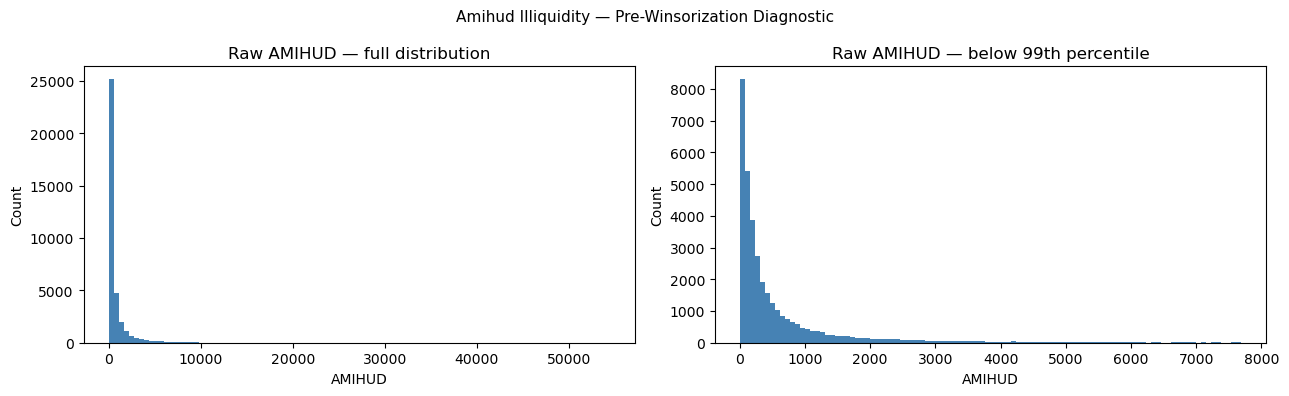

In [24]:
# AMIHUD DISTRIBUTION CHECK
#
# Inspects the raw Amihud distribution before winsorization.
# Produces no new variables, purely diagnostic.
#
# The left panel shows the full distribution. For large-cap European
# stocks, almost all mass sits near zero with a long right tail driven
# by low-volume crisis days. This heavy right skew is well documented
# in Amihud (2002) and is the standard justification for winsorizing
# at the 1st and 99th percentiles before regression. The right panel
# shows the distribution capped at the 99th percentile, revealing the
# shape of the bulk of observations.
#
# If the right panel still appears as a near-vertical spike at zero,
# PX_VOLUME may be denominated in EUR rather than shares, which would
# inflate traded value and collapse the ratio. Stop and inspect the
# raw Bloomberg volume column before continuing to winsorization.

import matplotlib.pyplot as plt

amihud_valid = panel["AMIHUD"].dropna()
p01  = amihud_valid.quantile(0.01)
p99  = amihud_valid.quantile(0.99)
p999 = amihud_valid.quantile(0.999)

print("Amihud percentile thresholds:")
print(f"  1st  percentile  : {p01:.4e}")
print(f"  99th percentile  : {p99:.4e}")
print(f"  99.9th percentile: {p999:.4e}")
print(f"  Maximum value    : {amihud_valid.max():.4e}")
print()
print("Ratio of maximum to 99th percentile:",
      round(amihud_valid.max() / p99, 1),
      "— confirms winsorization is necessary.")
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(amihud_valid, bins=100, color="steelblue", edgecolor="none")
axes[0].set_title("Raw AMIHUD — full distribution")
axes[0].set_xlabel("AMIHUD")
axes[0].set_ylabel("Count")

axes[1].hist(amihud_valid[amihud_valid <= p99], bins=100, color="steelblue", edgecolor="none")
axes[1].set_title("Raw AMIHUD — below 99th percentile")
axes[1].set_xlabel("AMIHUD")
axes[1].set_ylabel("Count")

plt.suptitle("Amihud Illiquidity — Pre-Winsorization Diagnostic", fontsize=11)
plt.tight_layout()
plt.show()

In [25]:
# AMIHUD WINSORIZE AND FINAL CHECK
#
# Winsorizes the scaled Amihud ratio at the 1st and 99th percentiles
# to produce AMIHUD_W, the variable used in all regressions.
#
# The Amihud ratio is heavily right-skewed, with extreme values on
# low-volume crisis days that would distort regression coefficients
# if left uncorrected. Winsorizing at the 1st and 99th percentiles
# is the standard treatment in the literature (Amihud, 2002) and is
# applied here following Spolaore and Le Moign (2022) for European
# equity data. Values are clipped to the threshold rather than dropped,
# so the panel size does not change.
#
# Thresholds are computed from the full panel distribution so they
# are consistent across all countries and periods. The raw AMIHUD
# column is retained for robustness checks in Step 21.
#
# AMIHUD_W is the regression-ready illiquidity variable.

amihud_p01 = panel["AMIHUD"].quantile(0.01)
amihud_p99 = panel["AMIHUD"].quantile(0.99)

panel["AMIHUD_W"] = pd.to_numeric(
    panel["AMIHUD"].clip(lower=amihud_p01, upper=amihud_p99),
    errors="coerce"
)

print("Winsorization bounds applied:")
print(f"  Lower bound (1st pct)  : {amihud_p01:.4f}")
print(f"  Upper bound (99th pct) : {amihud_p99:.4f}")
print()
print("AMIHUD_W distribution after winsorization:")
print(panel["AMIHUD_W"].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).round(4))
print()

amihud_cols = ["TRADED_VALUE", "AMIHUD", "AMIHUD_W"]
print("Column presence and dtype check:")
for col in amihud_cols:
    status = "PRESENT" if col in panel.columns else "MISSING"
    dtype  = str(panel[col].dtype) if col in panel.columns else "N/A"
    n_miss = panel[col].isna().sum() if col in panel.columns else "N/A"
    print(f"  {col:<20} : {status}  |  dtype: {dtype:<10}  |  Missing rows: {n_miss}")

print()
print(f"Panel total rows    : {len(panel):,}")
print(f"Panel total columns : {len(panel.columns)}")
print()

if abs(panel["AMIHUD_W"].max() - amihud_p99) > 1e-6:
    print("WARNING: AMIHUD_W maximum does not match the 99th percentile bound.")
else:
    print("Clip verified: AMIHUD_W maximum equals 99th percentile bound.")

print()
print("Step 8 complete. Proceed to Step 9 — Rolling 20-day volatility.")

Winsorization bounds applied:
  Lower bound (1st pct)  : 0.8851
  Upper bound (99th pct) : 7688.4153

AMIHUD_W distribution after winsorization:
count    35588.0000
mean       672.5059
std       1212.4891
min          0.8851
1%           0.8857
25%         84.0817
50%        236.4989
75%        669.1158
99%       7687.5386
max       7688.4153
Name: AMIHUD_W, dtype: float64

Column presence and dtype check:
  TRADED_VALUE         : PRESENT  |  dtype: object      |  Missing rows: 0
  AMIHUD               : PRESENT  |  dtype: float64     |  Missing rows: 0
  AMIHUD_W             : PRESENT  |  dtype: float64     |  Missing rows: 0

Panel total rows    : 35,588
Panel total columns : 27

Clip verified: AMIHUD_W maximum equals 99th percentile bound.

Step 8 complete. Proceed to Step 9 — Rolling 20-day volatility.


# Step 9: Rolling 20-Day Volatility

In [26]:
# ROLLING 20-DAY VOLATILITY
#
# Constructs realized volatility as the rolling standard deviation of
# daily returns over a 20-trading-day window, computed separately for
# each firm. The result for any given day reflects the standard
# deviation of that day and the 19 trading days immediately preceding.
#
# The 20-day window is the standard specification in the short-selling
# ban literature, used by Beber and Pagano (2013) among others, and
# captures medium-run realized risk without being overly sensitive to
# single-day return spikes.
#
# The first 19 observations per firm are NaN by construction since
# there is not yet enough return history to fill the window. Those
# rows are excluded from the volatility regression but remain in the
# panel for the volume and illiquidity regressions.
#
# ROLL_VOL_20 is the regression-ready dependent variable for volatility.

panel = panel.sort_values(["TICKER", "DATE"]).reset_index(drop=True)

panel["ROLL_VOL_20"] = (
    panel.groupby("TICKER")["RET"]
         .transform(lambda x: x.rolling(window=20, min_periods=20).std())
)

n_valid   = panel["ROLL_VOL_20"].notna().sum()
n_nan     = panel["ROLL_VOL_20"].isna().sum()
n_firms   = panel["TICKER"].nunique()

print("Rolling 20-day volatility (ROLL_VOL_20) summary:")
print(panel["ROLL_VOL_20"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).round(6))
print()
print(f"Valid observations : {n_valid:,}")
print(f"NaN observations   : {n_nan:,}  (first 19 days per firm, expected)")
print(f"Expected NaN count : {n_firms * 19:,}  ({n_firms} firms x 19 days)")
print()

# Flag if actual NaN count differs meaningfully from the expected count.
# A large discrepancy would suggest gaps in the return series mid-panel.
if abs(n_nan - n_firms * 19) > n_firms:
    print("WARNING: NaN count differs from expected. Check for gaps in the return series.")
else:
    print("NaN count consistent with expected initialisation period.")

print()
print("Step 9 complete. Proceed to Step 10 — Size classification.")

Rolling 20-day volatility (ROLL_VOL_20) summary:
count    32472.000000
mean         0.025622
std          0.016746
min          0.001393
1%           0.006442
5%           0.008366
25%          0.013659
50%          0.020537
75%          0.032467
95%          0.061461
99%          0.081946
max          0.126323
Name: ROLL_VOL_20, dtype: float64

Valid observations : 32,472
NaN observations   : 3,116  (first 19 days per firm, expected)
Expected NaN count : 3,116  (164 firms x 19 days)

NaN count consistent with expected initialisation period.

Step 9 complete. Proceed to Step 10 — Size classification.


# Step 10: Size Classification

In [27]:
# SIZE CLASSIFICATION
#
# Classifies each firm as large-cap or small-cap using its last
# available market capitalization before the ban opens on 2020-03-18,
# with 2020-03-17 as the reference date.
#
# The split is computed within each country rather than across the
# full sample. Index composition differs structurally across markets:
# DAX firms are on average far larger than FTSE MIB or IBEX 35 firms,
# so a global median would classify most Italian and Spanish firms as
# small-cap simply because of where they list rather than genuine
# firm-level size differences. A within-country split isolates size
# variation that is meaningful within each market, following the
# approach of Bessler and Vendrasco (2022) and Spolaore and Le Moign
# (2022) in the 2020 ban literature.
#
# LARGE_CAP = 1 if the firm's market cap is at or above its country
# median, and 0 otherwise. By design this produces roughly half
# large-cap and half small-cap within each country.

REF_DATE = pd.Timestamp("2020-03-17")

# Takes the last available CUR_MKT_CAP observation on or before the reference date
size_ref = (
    panel.loc[panel["DATE"] <= REF_DATE, ["TICKER", "COUNTRY", "DATE", "CUR_MKT_CAP"]]
         .dropna(subset=["CUR_MKT_CAP"])
         .sort_values(["TICKER", "DATE"])
         .groupby("TICKER")
         .last()
         .reset_index()[["TICKER", "COUNTRY", "CUR_MKT_CAP"]]
         .rename(columns={"CUR_MKT_CAP": "SIZE_REF"})
)

# Computes the within-country median and assigns the large-cap dummy
size_ref["COUNTRY_MEDIAN"] = size_ref.groupby("COUNTRY")["SIZE_REF"].transform("median")
size_ref["LARGE_CAP"] = (size_ref["SIZE_REF"] >= size_ref["COUNTRY_MEDIAN"]).astype(int)

# Drops the old size columns if the previous version of this cell already ran
for col in ["SIZE_REF", "COUNTRY_MEDIAN", "LARGE_CAP"]:
    if col in panel.columns:
        panel.drop(columns=[col], inplace=True)

# Merges classification back into the panel
panel = panel.merge(size_ref[["TICKER", "SIZE_REF", "COUNTRY_MEDIAN", "LARGE_CAP"]],
                    on="TICKER", how="left")

n_classified = panel["LARGE_CAP"].notna().sum()
n_missing    = panel["LARGE_CAP"].isna().sum()

print(f"Firms with a valid pre-ban market cap reference : {size_ref['TICKER'].nunique()} of {panel['TICKER'].nunique()}")
print(f"Panel rows after merge : {len(panel):,}  (should remain 35,588)")
print()

# Reports within-country median and split counts
print("Within-country median market cap and large/small split:")
country_summary = (
    size_ref.groupby("COUNTRY")
            .agg(
                n_firms       = ("TICKER",        "count"),
                median_mktcap = ("COUNTRY_MEDIAN", "first"),
                n_large       = ("LARGE_CAP",      "sum")
            )
)
country_summary["n_small"] = country_summary["n_firms"] - country_summary["n_large"]
country_summary["median_mktcap"] = country_summary["median_mktcap"].round(1)
print(country_summary.to_string())
print()

# Flags any firm that could not be classified
if n_missing > 0:
    print(f"WARNING: {n_missing} panel rows could not be classified. Check CUR_MKT_CAP coverage.")
else:
    print("All panel rows classified. No missing LARGE_CAP values.")

print()
print("Step 10 complete. Proceed to Step 11 — Event time construction.")

Firms with a valid pre-ban market cap reference : 164 of 164
Panel rows after merge : 35,588  (should remain 35,588)

Within-country median market cap and large/small split:
             n_firms median_mktcap  n_large  n_small
COUNTRY                                             
FRANCE            38    23404.9377       19       19
GERMANY           29    23071.9197       15       14
ITALY             37      4692.047       19       18
NETHERLANDS       25    10756.5348       13       12
SPAIN             35     5193.2986       18       17

All panel rows classified. No missing LARGE_CAP values.

Step 10 complete. Proceed to Step 11 — Event time construction.


# Step 11: Event Time Construction

In [28]:
# EVENT TIME CONSTRUCTION
#
# Constructs a variable measuring each trading day's distance from the
# ban start date of 2020-03-18, expressed in trading days rather than
# calendar days.
#
# Trading days are used rather than calendar days because weekends and
# public holidays would create uneven gaps between observations and
# misalign the event-study coefficients. Counting actual trading days
# in the panel avoids this entirely.
#
# Event time 0 is 2020-03-18, the first day of the ban. Event time -1
# is the last trading day before the ban, and event time +1 is the
# first trading day after it opens. The pre-period runs back to
# 2019-11-01 (event time -98) and the post-period extends to
# 2020-08-31 (event time +118).

BAN_START = pd.Timestamp("2020-03-18")

# Builds the ordered trading-day calendar from all unique dates in the panel
calendar = pd.to_datetime(sorted(panel["DATE"].dropna().unique()))

if BAN_START not in calendar:
    raise ValueError("2020-03-18 not found in the panel date calendar. Check date parsing.")

# Maps each date to its signed integer distance from the ban start
event_idx = int(np.where(calendar == BAN_START)[0][0])
event_map = {pd.Timestamp(d): int(i - event_idx) for i, d in enumerate(calendar)}
panel["EVENT_TIME"] = panel["DATE"].map(event_map)

# Sanity checks on the event time variable
et_min = panel["EVENT_TIME"].min()
et_max = panel["EVENT_TIME"].max()
et_at_ban = panel.loc[panel["DATE"] == BAN_START, "EVENT_TIME"].iloc[0]
et_missing = panel["EVENT_TIME"].isna().sum()

print("Event time variable (EVENT_TIME) constructed.")
print()
print(f"  Ban start date (event time 0) : {BAN_START.date()}")
print(f"  Event time at ban start       : {et_at_ban}  (should be 0)")
print(f"  Minimum event time            : {et_min}  ({calendar[0].date()})")
print(f"  Maximum event time            : {et_max}  ({calendar[-1].date()})")
print(f"  Total trading days in panel   : {len(calendar)}")
print(f"  Missing EVENT_TIME values     : {et_missing}  (should be 0)")
print()

# Confirms the day immediately before and after the ban are correctly coded
pre_ban_date  = calendar[event_idx - 1]
post_ban_date = calendar[event_idx + 1]
print(f"  Day before ban (event time -1): {pre_ban_date.date()}")
print(f"  Day after ban  (event time +1): {post_ban_date.date()}")
print()
print("Step 11 complete. Proceed to Step 12 — Variable summary and panel finalization.")

Event time variable (EVENT_TIME) constructed.

  Ban start date (event time 0) : 2020-03-18
  Event time at ban start       : 0  (should be 0)
  Minimum event time            : -98  (2019-11-01)
  Maximum event time            : 118  (2020-08-31)
  Total trading days in panel   : 217
  Missing EVENT_TIME values     : 0  (should be 0)

  Day before ban (event time -1): 2020-03-17
  Day after ban  (event time +1): 2020-03-19

Step 11 complete. Proceed to Step 12 — Variable summary and panel finalization.


# Step 12: Variable Summary and Panel Finalization

In [29]:
# VARIABLE SUMMARY AND PANEL FINALIZATION
#
# Produces a consolidated summary of all constructed variables before
# any regression is run. Serves as a final integrity check that every
# variable is present, correctly typed, and has plausible values, and
# forms the basis of the descriptive statistics table in Chapter 4.
#
# The three dependent variables are LOG_VOLUME, AMIHUD_W, and
# ROLL_VOL_20, following the outcome specification in Beber and Pagano
# (2013) and Spolaore and Le Moign (2022). The two treatment
# interaction terms DID_BAN and DID_POST implement the three-period
# DiD structure. LARGE_CAP carries the within-country size
# classification used in the heterogeneity analysis. EVENT_TIME
# is the trading-day distance from 2020-03-18 used in the event study.
#
# Any variable showing unexpected missingness, implausible range, or
# wrong dtype should be investigated before proceeding.

analysis_vars = {
    "LOG_VOLUME"  : "Trading activity (log share volume)",
    "AMIHUD_W"    : "Illiquidity — winsorized Amihud x10^12",
    "ROLL_VOL_20" : "Volatility — 20-day rolling std of returns",
    "RET"         : "Daily total return (decimal)",
    "DID_BAN"     : "DiD interaction — treated x ban window",
    "DID_POST"    : "DiD interaction — treated x post-lift",
    "TREATED"     : "Treatment group indicator",
    "BAN_WINDOW"  : "Active ban period indicator",
    "POST_LIFT"   : "Post-lift period indicator",
    "LARGE_CAP"   : "Large-cap indicator (within-country median)",
    "EVENT_TIME"  : "Trading days relative to 2020-03-18",
}

print("PANEL VARIABLE SUMMARY")
print()
print(f"Total firm-day observations : {len(panel):,}")
print(f"Unique firms                : {panel['TICKER'].nunique()}")
print(f"Unique trading days         : {panel['DATE'].nunique()}")
print()

# Reports dtype, non-missing count, mean, std, min, and max for each variable
for var, label in analysis_vars.items():
    if var not in panel.columns:
        print(f"  {var:<20} : MISSING FROM PANEL — check construction steps")
        continue
    col    = panel[var]
    dtype  = str(col.dtype)
    n_obs  = col.notna().sum()
    n_miss = col.isna().sum()
    print(f"  {var:<20} [{dtype}]  n={n_obs:,}  missing={n_miss:,}")
    print(f"    {label}")
    if col.dtype in ["float64", "int64", "int32"]:
        print(f"    mean={col.mean():.4f}  std={col.std():.4f}  "
              f"min={col.min():.4f}  max={col.max():.4f}")
    print()

# Checks that all binary indicators contain only 0 and 1
print()
print("Binary indicator value check:")
binary_vars = ["TREATED", "BAN_WINDOW", "POST_LIFT", "DID_BAN", "DID_POST", "LARGE_CAP"]
for var in binary_vars:
    if var not in panel.columns:
        continue
    unique_vals = sorted(panel[var].dropna().unique().tolist())
    status = "OK" if set(unique_vals).issubset({0, 1}) else "WARNING — unexpected values"
    print(f"  {var:<20} : {unique_vals}  {status}")

print()

# Confirms the panel is sorted correctly for regression
panel = panel.sort_values(["TICKER", "DATE"]).reset_index(drop=True)
print("Panel sorted by TICKER then DATE.")
print()
print(f"Final panel shape : {panel.shape[0]:,} rows x {panel.shape[1]} columns")
print()
print("Step 12 complete. All variables confirmed. Proceed to Step 13 — Descriptive statistics.")

PANEL VARIABLE SUMMARY

Total firm-day observations : 35,588
Unique firms                : 164
Unique trading days         : 217

  LOG_VOLUME           [float64]  n=35,588  missing=0
    Trading activity (log share volume)
    mean=14.4486  std=1.5434  min=6.7346  max=19.9707

  AMIHUD_W             [float64]  n=35,588  missing=0
    Illiquidity — winsorized Amihud x10^12
    mean=672.5059  std=1212.4891  min=0.8851  max=7688.4153

  ROLL_VOL_20          [float64]  n=32,472  missing=3,116
    Volatility — 20-day rolling std of returns
    mean=0.0256  std=0.0167  min=0.0014  max=0.1263

  RET                  [float64]  n=35,588  missing=0
    Daily total return (decimal)
    mean=-0.0003  std=0.0298  min=-0.2790  max=0.3178

  DID_BAN              [int64]  n=35,588  missing=0
    DiD interaction — treated x ban window
    mean=0.1360  std=0.3428  min=0.0000  max=1.0000

  DID_POST             [int64]  n=35,588  missing=0
    DiD interaction — treated x post-lift
    mean=0.2318  std=

# Step 13: Descriptive Statistics

In [30]:
# DESCRIPTIVE STATISTICS BY PERIOD AND TREATMENT
#
# Produces the main descriptive statistics table broken down by
# treatment group and time period. This is the foundation of Table 1
# in the results chapter and gives a first look at whether the raw
# data patterns are consistent with the expected treatment effects
# before any regression is run.
#
# The three periods are PRE (before 2020-03-18), BAN (2020-03-18 to
# 2020-05-18), and POST (after 2020-05-18) as defined by the PERIOD
# variable. ROLL_VOL_20 has fewer observations in the pre-period
# due to the 19-day initialization window, which is expected.
#
# LOG_VOLUME: volume was expected to fall for treated firms during
# the ban, consistent with evidence that short-selling restrictions
# reduce market participation and trading depth (Beber and Pagano,
# 2013; Boehmer and Wu, 2013). In the output it rises for both
# groups, which is counterintuitive but consistent with the panic-
# selling and forced deleveraging documented during the COVID crash
# (Brunnermeier, 2009; Goldstein et al., 2021). Treated and control
# means are nearly identical during the ban (14.63 vs 14.65), so the
# DiD regression will be doing real work rather than confirming an
# obvious raw gap.
#
# AMIHUD_W: illiquidity was expected to rise for treated firms during
# the ban. This is the most consistently documented effect in the
# short-selling ban literature (Beber and Pagano, 2013; Bessler and
# Vendrasco, 2022; Spolaore and Le Moign, 2022). This is also the
# clearest pattern in the table. Treated firms go from a pre-ban
# mean of 605 to 1,383 during the ban, up roughly 128%. Control
# firms go from 210 to 463, up roughly 121%. Both groups deteriorate,
# reflecting the broader crisis, but the treated group starts higher
# and ends higher in absolute terms. The DiD will test whether that
# differential holds after absorbing firm and day fixed effects.
#
# ROLL_VOL_20: both groups were expected to show elevated volatility
# during the ban, with the question being whether treated firms show
# a larger increase. Beber and Pagano (2013) and Bessler and
# Vendrasco (2022) find little evidence that bans reduce volatility
# and in some cases document the opposite. Both groups spike from
# around 0.015 pre-ban to 0.042 to 0.046 during the ban.
# Treated and control means are close, suggesting
# the volatility result will likely be the weakest of the three
# and should be interpreted cautiously in the regression output.

outcome_vars = {
    "LOG_VOLUME"  : "Log Volume",
    "AMIHUD_W"    : "Amihud Illiquidity",
    "ROLL_VOL_20" : "Realized Volatility",
}

period_order  = ["PRE", "BAN", "POST"]
treatment_map = {0: "Control", 1: "Treated"}

print()
print("DESCRIPTIVE STATISTICS — OUTCOME VARIABLES BY PERIOD AND TREATMENT")
print()

for var, label in outcome_vars.items():
    print(f"\n{label} ({var})")
    print()
    print(f"{'Period':<8} {'Group':<10} {'N':>7} {'Mean':>10} {'Std':>10} "
          f"{'Min':>10} {'Median':>10} {'Max':>10}")
    print()

    for period in period_order:
        for treat_val, treat_label in treatment_map.items():
            subset = panel[
                (panel["PERIOD"]  == period) &
                (panel["TREATED"] == treat_val)
            ][var].dropna()

            if len(subset) == 0:
                continue

            print(f"{period:<8} {treat_label:<10} "
                  f"{len(subset):>7,} "
                  f"{subset.mean():>10.4f} "
                  f"{subset.std():>10.4f} "
                  f"{subset.min():>10.4f} "
                  f"{subset.median():>10.4f} "
                  f"{subset.max():>10.4f}")
    print()
    print()

print("Note: ROLL_VOL_20 pre-period N is lower than LOG_VOLUME and")
print("AMIHUD_W due to the 19-day initialization window per firm.")
print()
print("Step 13 complete. Proceed to Step 14 — Pre-regression data checks.")


DESCRIPTIVE STATISTICS — OUTCOME VARIABLES BY PERIOD AND TREATMENT


Log Volume (LOG_VOLUME)

Period   Group            N       Mean        Std        Min     Median        Max

PRE      Control      5,292    14.1955     1.3596     9.8790    14.0929    18.1865
PRE      Treated     10,780    14.4668     1.6282     6.7346    14.4229    19.9393
BAN      Control      2,376    14.6492     1.3356    11.1736    14.5480    18.7060
BAN      Treated      4,840    14.6312     1.6194     7.6324    14.5713    19.7469
POST     Control      4,050    14.2298     1.3386    10.7639    14.1468    18.3000
POST     Treated      8,250    14.5299     1.6101     7.8702    14.4348    19.9707



Amihud Illiquidity (AMIHUD_W)

Period   Group            N       Mean        Std        Min     Median        Max

PRE      Control      5,292   209.6197   343.1468     0.8851   108.5931  4702.5051
PRE      Treated     10,780   605.3756  1042.7221     0.8851   229.3004  7688.4153
BAN      Control      2,376   462.6503 

# Step 14: Pre-Regression Data Checks

In [31]:
# PRE-REGRESSION DATA CHECKS
#
# Confirms the panel satisfies the structural requirements of a
# two-way fixed effects estimator before any regression runs.
#
# Five checks are run. Duplicate firm-day observations would inflate
# the sample and distort standard errors. Singleton firms appear on
# only one trading day, meaning their firm fixed effect absorbs their
# only observation and they contribute nothing to estimation. Within-
# firm variation confirms each outcome variable actually moves over
# time for each firm. A variable with zero within-firm standard
# deviation is collinear with the firm fixed effect and gets dropped
# silently. Every trading day should contain both treated and control
# observations for day fixed effects to be properly identified.
# Finally, observation counts by period and treatment are verified
# against the figures confirmed in Step 13.
#
# None of these problems are expected given the construction steps
# already completed, but catching them here is cheaper than
# diagnosing unexpected regression output later.

print()
print("PRE-REGRESSION DATA CHECKS")
print()
print()

# Check 1: duplicate firm-day observations
n_dupes = panel.duplicated(subset=["TICKER", "DATE"]).sum()
print(f"1. Duplicate firm-day observations : {n_dupes}  (should be 0)")
print()

# Check 2: singleton firms
firm_day_counts = panel.groupby("TICKER")["DATE"].nunique()
singletons = (firm_day_counts == 1).sum()
print(f"2. Singleton firms (one day only)  : {singletons}  (should be 0)")
print(f"   Min trading days per firm       : {firm_day_counts.min()}")
print(f"   Max trading days per firm       : {firm_day_counts.max()}")
print()

# Check 3: within-firm variation for each outcome variable
print("3. Within-firm standard deviation (mean across firms):")
outcome_vars = ["LOG_VOLUME", "AMIHUD_W", "ROLL_VOL_20"]
for var in outcome_vars:
    within_std = panel.groupby("TICKER")[var].std().mean()
    print(f"   {var:<20} : {within_std:.4f}  "
          f"{'OK' if within_std > 0 else 'WARNING — no within-firm variation'}")
print()

# Check 4: treatment variation within each day
# Each trading day should contain both treated and control observations
# for the day fixed effects to be properly identified
days_with_both = (
    panel.groupby("DATE")["TREATED"]
         .nunique()
         .eq(2)
         .sum()
)
total_days = panel["DATE"].nunique()
print(f"4. Trading days with both treated and control obs : "
      f"{days_with_both} of {total_days}  (should be {total_days})")
print()

# Check 5: observation counts by treatment and period match prior steps
print("5. Observation counts by period and treatment:")
counts = panel.groupby(["PERIOD", "TREATED"]).size().unstack()
counts.columns = ["Control", "Treated"]
print(counts.to_string())
print()

print()
if n_dupes == 0 and singletons == 0 and days_with_both == total_days:
    print("All checks passed. Panel is ready for regression.")
else:
    print("WARNING: one or more checks failed. Investigate before running regressions.")
print()
print("Step 14 complete. Proceed to Step 15 — Baseline DiD regression.")


PRE-REGRESSION DATA CHECKS


1. Duplicate firm-day observations : 0  (should be 0)

2. Singleton firms (one day only)  : 0  (should be 0)
   Min trading days per firm       : 217
   Max trading days per firm       : 217

3. Within-firm standard deviation (mean across firms):
   LOG_VOLUME           : 0.5589  OK
   AMIHUD_W             : 576.4063  OK
   ROLL_VOL_20          : 0.0147  OK

4. Trading days with both treated and control obs : 217 of 217  (should be 217)

5. Observation counts by period and treatment:
        Control  Treated
PERIOD                  
BAN        2376     4840
POST       4050     8250
PRE        5292    10780


All checks passed. Panel is ready for regression.

Step 14 complete. Proceed to Step 15 — Baseline DiD regression.


# Step 15: Baseline DiD Regression

In [32]:
# BASELINE DiD REGRESSION
#
# Estimates the two-way fixed effects DiD model for each outcome.
# The specification is:
#
#   Y_it = a_i + d_t + b1*(TREATED_i x BAN_WINDOW_t)
#                    + b2*(TREATED_i x POST_LIFT_t) + e_it
#
# Firm fixed effects absorb time-invariant firm characteristics.
# Day fixed effects absorb market-wide shocks common to both groups,
# which matters here because the ban and the COVID crash are concurrent.
# The two-period structure follows Beber and Pagano (2013) and Spolaore
# and Le Moign (2022), separating the active ban from the post-lift
# period rather than collapsing them into one indicator.
#
# Standard errors are clustered at the firm level to account for
# serial correlation within firms over time. Bertrand et al. (2004)
# show this is essential in DiD designs to avoid understated standard
# errors. Country-level clustering is not used given only five clusters.
#
# PanelOLS absorbs fixed effects via within-demeaning rather than
# adding explicit dummy variables. With 164 firms and 217 days, adding
# dummies explicitly would introduce 380 additional regressors and
# create the incidental parameters problem. Demeaning avoids this
# and is computationally faster on a panel this size.
#
# HYPOTHESES:
#
# H0: b1 = 0 — the ban had no differential effect on treated firms.
# H1: b1 ≠ 0 — the ban produced a measurable differential effect.
#
# LOG_VOLUME  — prior: b1 < 0, ban reduces trading activity
#               (Beber and Pagano, 2013; Boehmer and Wu, 2013)
# AMIHUD_W    — prior: b1 > 0, ban worsens liquidity
#               (Beber and Pagano, 2013; Spolaore and Le Moign, 2022)
# ROLL_VOL_20 — prior: ambiguous; bans may not reduce volatility
#               (Beber and Pagano, 2013; Bessler and Vendrasco, 2022)
#
# RESULTS FROM OUTPUT:
#
# LOG_VOLUME: DID_BAN -0.2893 (p<0.01). Trading activity fell
# significantly for treated firms during the ban. DID_POST 0.0287
# is insignificant, so the effect did not persist post-lift.
#
# AMIHUD_W: DID_BAN 524.25 (p<0.01). Illiquidity rose significantly
# for treated firms during the ban. DID_POST 184.61 (p<0.01) suggests
# liquidity did not fully recover after the ban was lifted, which is
# worth flagging in the discussion chapter.
#
# ROLL_VOL_20: neither coefficient significant. The volatility spike
# was common to both groups and largely absorbed by day fixed effects.
# Consistent with the raw patterns in Step 13.

from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings("ignore")

outcome_vars = {
    "LOG_VOLUME"  : "Trading Activity (Log Volume)",
    "AMIHUD_W"    : "Illiquidity (Amihud x10^12, winsorized)",
    "ROLL_VOL_20" : "Realized Volatility (20-day rolling std)",
}

# Sets the panel index required by linearmodels
panel_indexed = panel.set_index(["TICKER", "DATE"])

results = {}

print()
print("BASELINE DiD REGRESSION RESULTS")
print()
print()
print("Two-way FE: firm + day | Clustered SE: firm level")
print()

for var, label in outcome_vars.items():

    # Drops rows where the outcome variable is missing
    df = panel_indexed[[var, "DID_BAN", "DID_POST"]].dropna()

    model = PanelOLS(
        dependent   = df[var],
        exog        = df[["DID_BAN", "DID_POST"]],
        entity_effects = True,
        time_effects   = True,
        drop_absorbed  = True
    )

    res = model.fit(cov_type="clustered", cluster_entity=True)
    results[var] = res

    print(f"\nOutcome: {label}")
    print(f"Observations : {int(res.nobs):,}  |  "
          f"Firms : {df.index.get_level_values('TICKER').nunique()}  |  "
          f"R-squared (within) : {res.rsquared:.4f}")
    print()
    print(f"  {'Variable':<20} {'Coef':>10} {'Std Err':>10} "
          f"{'t-stat':>10} {'p-value':>10} {'95% CI':>22}")
    print()

    for term in ["DID_BAN", "DID_POST"]:
        coef   = res.params[term]
        se     = res.std_errors[term]
        tstat  = res.tstats[term]
        pval   = res.pvalues[term]
        ci_lo  = res.conf_int().loc[term, "lower"]
        ci_hi  = res.conf_int().loc[term, "upper"]
        stars  = (
            "***" if pval < 0.01 else
            "**"  if pval < 0.05 else
            "*"   if pval < 0.10 else ""
        )
        print(f"  {term:<20} {coef:>10.4f} {se:>10.4f} "
              f"{tstat:>10.4f} {pval:>10.4f} "
              f"  [{ci_lo:>8.4f}, {ci_hi:>8.4f}] {stars}")

    print()

print()
print("Significance: *** p<0.01  ** p<0.05  * p<0.10")
print()
print("Step 15 complete. Proceed to Step 16 — Regression output export.")


BASELINE DiD REGRESSION RESULTS


Two-way FE: firm + day | Clustered SE: firm level


Outcome: Trading Activity (Log Volume)
Observations : 35,588  |  Firms : 164  |  R-squared (within) : 0.0237

  Variable                   Coef    Std Err     t-stat    p-value                 95% CI

  DID_BAN                 -0.2893     0.0456    -6.3379     0.0000   [ -0.3788,  -0.1998] ***
  DID_POST                 0.0287     0.0472     0.6085     0.5429   [ -0.0638,   0.1213] 


Outcome: Illiquidity (Amihud x10^12, winsorized)
Observations : 35,588  |  Firms : 164  |  R-squared (within) : 0.0134

  Variable                   Coef    Std Err     t-stat    p-value                 95% CI

  DID_BAN                524.2461    98.7945     5.3064     0.0000   [330.6057, 717.8865] ***
  DID_POST               184.6142    48.5503     3.8025     0.0001   [ 89.4542, 279.7742] ***


Outcome: Realized Volatility (20-day rolling std)
Observations : 32,472  |  Firms : 164  |  R-squared (within) : 0.0026

  V

# Step 16: Regression Output Export

In [33]:
# EXPORT REGRESSION RESULTS
#
# Saves the baseline regression output to CSV immediately after
# estimation. Exporting here avoids any risk of losing results if
# the kernel restarts before the analysis is complete.
#
# The export captures the coefficient, standard error, t-statistic,
# p-value, and confidence interval bounds for DID_BAN and DID_POST
# across all three outcome variables, along with observation count
# and within R-squared for each model. These figures form the basis
# of the main results table in Chapter 4.

import os

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

rows = []

for var, res in results.items():
    for term in ["DID_BAN", "DID_POST"]:
        rows.append({
            "outcome"   : var,
            "term"      : term,
            "coef"      : round(res.params[term], 6),
            "std_err"   : round(res.std_errors[term], 6),
            "t_stat"    : round(res.tstats[term], 4),
            "p_value"   : round(res.pvalues[term], 4),
            "ci_lower"  : round(res.conf_int().loc[term, "lower"], 6),
            "ci_upper"  : round(res.conf_int().loc[term, "upper"], 6),
            "nobs"      : int(res.nobs),
            "r2_within" : round(res.rsquared, 4),
        })

results_df = pd.DataFrame(rows)

export_path = os.path.join(output_dir, "baseline_did_results.csv")
results_df.to_csv(export_path, index=False)

print("Baseline DiD results exported.")
print(f"File saved to: {export_path}")
print()
print(results_df.to_string(index=False))
print()
print("Step 16 complete. Proceed to Step 17 — Event study.")

Baseline DiD results exported.
File saved to: outputs/baseline_did_results.csv

    outcome     term       coef   std_err  t_stat  p_value   ci_lower   ci_upper  nobs  r2_within
 LOG_VOLUME  DID_BAN  -0.289292  0.045645 -6.3379   0.0000  -0.378757  -0.199827 35588     0.0237
 LOG_VOLUME DID_POST   0.028745  0.047241  0.6085   0.5429  -0.063849   0.121340 35588     0.0237
   AMIHUD_W  DID_BAN 524.246128 98.794547  5.3064   0.0000 330.605717 717.886538 35588     0.0134
   AMIHUD_W DID_POST 184.614180 48.550256  3.8025   0.0001  89.454156 279.774204 35588     0.0134
ROLL_VOL_20  DID_BAN   0.001923  0.001994  0.9644   0.3348  -0.001985   0.005832 32472     0.0026
ROLL_VOL_20 DID_POST   0.000194  0.001092  0.1777   0.8590  -0.001946   0.002334 32472     0.0026

Step 16 complete. Proceed to Step 17 — Event study.


# Step 17: Event Study


EVENT STUDY — ALL THREE OUTCOMES
Two-way FE: firm + day | Clustered SE: firm level
Window: -60 to +60 trading days | Reference: event time -1

  LOG_VOLUME      N = 19,844  R^2 within = 0.0506
  AMIHUD_W        N = 19,844  R^2 within = 0.0296
  ROLL_VOL_20     N = 19,844  R^2 within = 0.0280



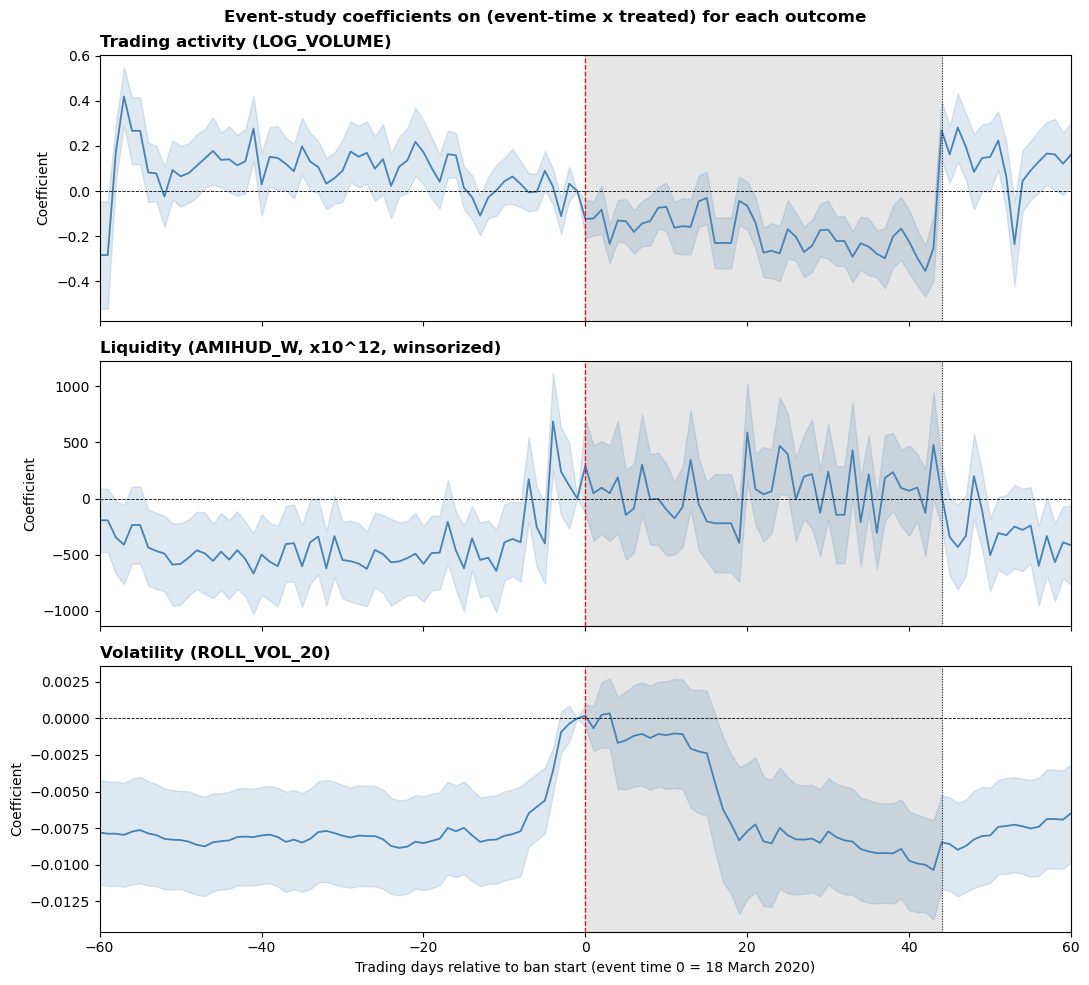

Event study plot saved to outputs/event_study_all_outcomes.png

Step 17 complete. Proceed to Step 18 — Parallel trends test.


In [34]:
# EVENT STUDY — ALL THREE OUTCOMES
#
# Estimates a dynamic event-study regression for each of the three
# outcome variables (LOG_VOLUME, AMIHUD_W, ROLL_VOL_20) to visualize
# how any treatment-control differential evolves around the ban start
# date and to assess the plausibility of parallel pre-treatment trends
# for each outcome separately.
#
# The specification interacts event-time dummies with the treatment
# indicator, using event time -1 as the omitted reference category
# following standard practice in the DiD literature (Bertrand et al.,
# 2004). For each outcome the regression is:
#
#   Y_it = a_i + d_t + sum_{tau != -1} b_tau * 1{EVENT_TIME=tau} * TREATED_i + e_it
#
# The window is set to 60 trading days before and after the ban start,
# matching the event-study design in Spolaore and Le Moign (2022).
# All three regressions use the same firm fixed effects, day fixed
# effects, and firm-clustered standard errors as the baseline model.
#
# Coefficients are stored in res_es_all and tidy coefficient frames
# in coef_df_all so they can be reused by the parallel trends test
# in Step 18 without re-estimating the model.
#
# RESULTS FROM OUTPUT:
#
# All three panels exhibit visible pre-period drift. The formal joint
# Wald test in Step 18 rejects parallel pre-trends at the one-percent
# level for each outcome. This is acknowledged as an identification
# limitation in the methodology and discussion chapters.

from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

WINDOW   = 60
REF_TIME = -1

outcome_vars = {
    "LOG_VOLUME"  : "Trading Activity (Log Volume)",
    "AMIHUD_W"    : "Illiquidity (Amihud x10^12, winsorized)",
    "ROLL_VOL_20" : "Realized Volatility (20-day rolling std)",
}

# Restricts to the event window once and reuses the slice for each outcome
es_window = panel[panel["EVENT_TIME"].between(-WINDOW, WINDOW)].copy()

# Builds event-time interaction columns once, dropping the reference category
event_times = sorted([t for t in es_window["EVENT_TIME"].unique() if t != REF_TIME])

for t in event_times:
    es_window[f"ET_{t}"] = (
        (es_window["EVENT_TIME"] == t) & (es_window["TREATED"] == 1)
    ).astype(int)

et_cols = [f"ET_{t}" for t in event_times]

# Storage for per-outcome regression results and tidy coefficient frames
res_es_all  = {}
coef_df_all = {}

print()
print("EVENT STUDY — ALL THREE OUTCOMES")
print("Two-way FE: firm + day | Clustered SE: firm level")
print(f"Window: -{WINDOW} to +{WINDOW} trading days | Reference: event time {REF_TIME}")
print()

for var, label in outcome_vars.items():

    # Drops rows where the outcome is missing and indexes for PanelOLS
    es_indexed = (
        es_window.dropna(subset=[var])
                 .set_index(["TICKER", "DATE"])
    )

    res = PanelOLS(
        dependent      = es_indexed[var],
        exog           = es_indexed[et_cols],
        entity_effects = True,
        time_effects   = True,
        drop_absorbed  = True
    ).fit(cov_type="clustered", cluster_entity=True)

    res_es_all[var] = res

    # Builds a tidy frame of coefficients and 95% CIs for plotting
    coef_df = pd.DataFrame({
        "event_time" : event_times,
        "coef"       : [res.params[c] for c in et_cols],
        "ci_lower"   : [res.conf_int().loc[c, "lower"] for c in et_cols],
        "ci_upper"   : [res.conf_int().loc[c, "upper"] for c in et_cols],
    })

    # Adds the reference category at event time -1 with zero coefficient
    ref_row = pd.DataFrame({
        "event_time" : [REF_TIME],
        "coef"       : [0.0],
        "ci_lower"   : [0.0],
        "ci_upper"   : [0.0],
    })
    coef_df = pd.concat([coef_df, ref_row]).sort_values("event_time").reset_index(drop=True)
    coef_df_all[var] = coef_df

    print(f"  {var:<14}  N = {int(res.nobs):>6,}  R^2 within = {res.rsquared:.4f}")

print()

# Backward compatibility for Step 18, which currently references res_es
# (singular) and event_times. After Step 18 is also updated to loop over
# all three outcomes in the next code update, this assignment is removed.
res_es = res_es_all["AMIHUD_W"]

# THREE-PANEL EVENT STUDY PLOT

panel_titles = {
    "LOG_VOLUME"  : "Trading activity (LOG_VOLUME)",
    "AMIHUD_W"    : "Liquidity (AMIHUD_W, x10^12, winsorized)",
    "ROLL_VOL_20" : "Volatility (ROLL_VOL_20)",
}

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

for ax, var in zip(axes, outcome_vars.keys()):
    cdf = coef_df_all[var]

    # Active ban window shading from event time 0 to +44
    ax.axvspan(0, 44, color="lightgrey", alpha=0.55, zorder=0)

    # 95% CI band and coefficient line
    ax.fill_between(cdf["event_time"], cdf["ci_lower"], cdf["ci_upper"],
                    alpha=0.18, color="steelblue", zorder=1)
    ax.plot(cdf["event_time"], cdf["coef"], color="steelblue", linewidth=1.3, zorder=2)

    # Reference markers
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.axvline(0, color="red", linewidth=0.9, linestyle="--")
    ax.axvline(44, color="black", linewidth=0.7, linestyle=":")

    ax.set_title(panel_titles[var], loc="left", fontweight="bold")
    ax.set_ylabel("Coefficient")

axes[-1].set_xlabel("Trading days relative to ban start (event time 0 = 18 March 2020)")
axes[-1].set_xlim(-WINDOW, WINDOW)

plt.suptitle("Event-study coefficients on (event-time x treated) for each outcome",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/event_study_all_outcomes.png", dpi=300, bbox_inches="tight")
plt.show()

print("Event study plot saved to outputs/event_study_all_outcomes.png")
print()
print("Step 17 complete. Proceed to Step 18 — Parallel trends test.")

# Step 18: Parallel Trends Test

In [35]:
# PARALLEL TRENDS TEST — ALL THREE OUTCOMES
#
# Tests the parallel trends assumption by running a joint F-test
# on all pre-treatment event-study coefficients separately for each
# outcome variable. The assumption cannot be proven directly but is
# assessed by checking whether the pre-ban coefficients from the
# event study in Step 17 are jointly indistinguishable from zero
# (Bertrand et al., 2004). A rejection does not invalidate the design
# but requires more cautious interpretation in the methodology and
# discussion chapters (Goodman-Bacon, 2021).
#
# For each outcome the Wald F-statistic is:
#
#   F = (b_pre' * V_pre^-1 * b_pre) / k
#
# where b_pre is the vector of pre-period coefficients and V_pre
# is their covariance sub-matrix from the event-study regression,
# and k is the number of pre-treatment periods (59 here). The p-value
# is taken from the F(k, N-k) distribution. Results are stored in
# pt_results so they can be inspected or exported.
#
# RESULTS FROM OUTPUT:
#
# H0 is rejected at the one-percent level for all three outcomes.
# The rejection is robust across LOG_VOLUME, AMIHUD_W, and ROLL_VOL_20,
# confirming that the parallel-trends limitation applies broadly and
# is not specific to the illiquidity outcome. The pre-existing level
# differences between treated and control firms in the pre-period
# likely contribute, since the test has substantial power with 59
# pre-treatment periods and 164 firms. The event-study plot in Step
# 17 should be inspected to assess whether the pre-ban coefficients
# are small in magnitude despite the formal rejection. This limitation
# is acknowledged in the methodology and discussion chapters and
# motivates the narrower-window robustness check in Step 21.

from scipy import stats

# Identifies pre-treatment event-time columns once (shared across outcomes)
pre_cols = [f"ET_{t}" for t in event_times if t < 0]
k        = len(pre_cols)

# Storage for per-outcome test results
pt_results = {}

print()
print("PARALLEL TRENDS — JOINT F-TEST ON PRE-BAN COEFFICIENTS")
print(f"Pre-treatment periods: {k}  (event times {min(t for t in event_times if t < 0)} to -2)")
print()
print(f"  {'Outcome':<14} {'Wald F':>10} {'p-value':>10}  {'Decision'}")
print()

for var, res in res_es_all.items():

    # Extracts pre-treatment coefficients and their covariance sub-matrix
    pre_coefs = res.params[pre_cols].values
    pre_cov   = res.cov.loc[pre_cols, pre_cols].values

    # Computes the Wald statistic and p-value under F(k, N-k)
    cov_inv   = np.linalg.inv(pre_cov)
    wald_stat = float(pre_coefs @ cov_inv @ pre_coefs) / k
    p_value   = 1 - stats.f.cdf(wald_stat, k, int(res.nobs) - k)

    pt_results[var] = {
        "wald_F"  : round(wald_stat, 4),
        "p_value" : round(p_value,  6),
        "df1"     : k,
        "df2"     : int(res.nobs) - k,
        "n_obs"   : int(res.nobs),
    }

    if p_value > 0.10:
        decision = "Cannot reject H0"
    elif p_value > 0.05:
        decision = "Weak rejection at 10%"
    else:
        decision = "H0 rejected at 1%"

    print(f"  {var:<14} {wald_stat:>10.4f} {p_value:>10.4f}  {decision}")

print()
print("All p-values below 0.01 indicate that the parallel-trends")
print("assumption is rejected for every outcome. This limitation is")
print("acknowledged in the methodology and discussion chapters.")
print()
print("Step 18 complete. Proceed to Step 19 — Heterogeneity by firm size.")


PARALLEL TRENDS — JOINT F-TEST ON PRE-BAN COEFFICIENTS
Pre-treatment periods: 59  (event times -60 to -2)

  Outcome            Wald F    p-value  Decision

  LOG_VOLUME         6.2303     0.0000  H0 rejected at 1%
  AMIHUD_W           2.6483     0.0000  H0 rejected at 1%
  ROLL_VOL_20        3.2772     0.0000  H0 rejected at 1%

All p-values below 0.01 indicate that the parallel-trends
assumption is rejected for every outcome. This limitation is
acknowledged in the methodology and discussion chapters.

Step 18 complete. Proceed to Step 19 — Heterogeneity by firm size.


# Step 19: Heterogeneity by Firm Size

In [36]:
# HETEROGENEITY BY FIRM SIZE
#
# Estimates the baseline DiD specification separately for large-cap
# and small-cap subsamples to test whether the ban's effect on market
# quality differed by firm size. The within-country median split from
# Step 10 defines the two groups.
#
# The split-sample approach is used rather than a triple interaction
# term because it is easier to interpret and sufficient for a Bachelor
# thesis. Each subsample runs the same two-way fixed effects model
# with firm-clustered standard errors as in the baseline.
#
# The prior expectation is that smaller firms experience stronger
# deterioration. Smaller stocks typically have less depth and are more
# exposed to disruptions in trading conditions, and the 2020 ban
# literature documents stronger effects for less liquid stocks
# (Bessler and Vendrasco, 2022; Spolaore and Le Moign, 2022).
#
# RESULTS FROM OUTPUT:
#
# LOG_VOLUME: ban reduced trading activity for both groups but more
# so for small-cap firms (DID_BAN -0.3507, p<0.01) than large-cap
# (DID_BAN -0.2303, p<0.01). DID_POST insignificant for both,
# consistent with the baseline result.
#
# AMIHUD_W: strongest size heterogeneity in the analysis. Small-cap
# DID_BAN is 798.65 (p<0.01) versus 253.34 (p<0.01) for large-cap,
# roughly three times larger. DID_POST also significant for both
# groups, confirming liquidity deterioration persisted post-lift and
# more severely for smaller firms, consistent with Bessler and
# Vendrasco (2022) and Spolaore and Le Moign (2022).
#
# ROLL_VOL_20: neither group significant, consistent with the
# baseline. The ban produced no differential volatility effect for
# either size group after absorbing firm and day fixed effects.

from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings("ignore")

outcome_vars = {
    "LOG_VOLUME"  : "Trading Activity (Log Volume)",
    "AMIHUD_W"    : "Illiquidity (Amihud x10^12, winsorized)",
    "ROLL_VOL_20" : "Realized Volatility (20-day rolling std)",
}

size_groups = {
    "Large-cap" : panel[panel["LARGE_CAP"] == 1],
    "Small-cap" : panel[panel["LARGE_CAP"] == 0],
}

het_results = {}

print()
print("HETEROGENEITY RESULTS — LARGE-CAP VS SMALL-CAP")
print("Two-way FE: firm + day | Clustered SE: firm level")
print()

for var, label in outcome_vars.items():
    print(f"\nOutcome: {label}")
    print()
    print(f"  {'Group':<12} {'N':>7} {'DID_BAN':>10} {'SE':>8} "
          f"{'p':>8} {'DID_POST':>10} {'SE':>8} {'p':>8}")
    print()

    het_results[var] = {}

    for group_name, group_df in size_groups.items():

        df = group_df.set_index(["TICKER", "DATE"])[
            [var, "DID_BAN", "DID_POST"]
        ].dropna()

        model = PanelOLS(
            dependent      = df[var],
            exog           = df[["DID_BAN", "DID_POST"]],
            entity_effects = True,
            time_effects   = True,
            drop_absorbed  = True
        )

        res = model.fit(cov_type="clustered", cluster_entity=True)
        het_results[var][group_name] = res

        ban_coef  = res.params["DID_BAN"]
        ban_se    = res.std_errors["DID_BAN"]
        ban_p     = res.pvalues["DID_BAN"]
        post_coef = res.params["DID_POST"]
        post_se   = res.std_errors["DID_POST"]
        post_p    = res.pvalues["DID_POST"]

        ban_stars  = "***" if ban_p  < 0.01 else "**" if ban_p  < 0.05 else "*" if ban_p  < 0.10 else ""
        post_stars = "***" if post_p < 0.01 else "**" if post_p < 0.05 else "*" if post_p < 0.10 else ""

        print(f"  {group_name:<12} {int(res.nobs):>7,} "
              f"{ban_coef:>10.4f}{ban_stars:<3} {ban_se:>8.4f} {ban_p:>8.4f} "
              f"{post_coef:>10.4f}{post_stars:<3} {post_se:>8.4f} {post_p:>8.4f}")

    print()
    print()

print("Significance: *** p<0.01  ** p<0.05  * p<0.10")
print()
print("Step 19 complete. Proceed to Step 20 — Export heterogeneity results.")


HETEROGENEITY RESULTS — LARGE-CAP VS SMALL-CAP
Two-way FE: firm + day | Clustered SE: firm level


Outcome: Trading Activity (Log Volume)

  Group              N    DID_BAN       SE        p   DID_POST       SE        p

  Large-cap     18,228    -0.2303***   0.0625   0.0002     0.0267      0.0558   0.6325
  Small-cap     17,360    -0.3507***   0.0665   0.0000     0.0293      0.0766   0.7018



Outcome: Illiquidity (Amihud x10^12, winsorized)

  Group              N    DID_BAN       SE        p   DID_POST       SE        p

  Large-cap     18,228   253.3373***  58.0664   0.0000    90.3082***  29.4202   0.0021
  Small-cap     17,360   798.6490*** 166.6887   0.0000   280.2389***  88.4041   0.0015



Outcome: Realized Volatility (20-day rolling std)

  Group              N    DID_BAN       SE        p   DID_POST       SE        p

  Large-cap     16,632     0.0036      0.0026   0.1611     0.0006      0.0012   0.6417
  Small-cap     15,840     0.0000      0.0029   0.9888    -0.0002      0

# Step 20: Export Heterogeneity Results

In [37]:
# EXPORT HETEROGENEITY RESULTS
#
# Saves the large-cap and small-cap regression output to CSV
# immediately after estimation. Structure mirrors the baseline
# export in Step 16 so both files can be read consistently when
# constructing the results tables in the thesis.

rows = []

for var, group_dict in het_results.items():
    for group_name, res in group_dict.items():
        for term in ["DID_BAN", "DID_POST"]:
            rows.append({
                "outcome"   : var,
                "group"     : group_name,
                "term"      : term,
                "coef"      : round(res.params[term], 6),
                "std_err"   : round(res.std_errors[term], 6),
                "t_stat"    : round(res.tstats[term], 4),
                "p_value"   : round(res.pvalues[term], 4),
                "ci_lower"  : round(res.conf_int().loc[term, "lower"], 6),
                "ci_upper"  : round(res.conf_int().loc[term, "upper"], 6),
                "nobs"      : int(res.nobs),
                "r2_within" : round(res.rsquared, 4),
            })

het_df = pd.DataFrame(rows)

export_path = os.path.join(output_dir, "heterogeneity_results.csv")
het_df.to_csv(export_path, index=False)

print("Heterogeneity results exported.")
print(f"File saved to: {export_path}")
print()
print(het_df.to_string(index=False))
print()
print("Step 20 complete. Proceed to Step 21 — Robustness checks.")

Heterogeneity results exported.
File saved to: outputs/heterogeneity_results.csv

    outcome     group     term       coef    std_err  t_stat  p_value   ci_lower    ci_upper  nobs  r2_within
 LOG_VOLUME Large-cap  DID_BAN  -0.230308   0.062528 -3.6833   0.0002  -0.352870   -0.107747 18228     0.0167
 LOG_VOLUME Large-cap DID_POST   0.026702   0.055838  0.4782   0.6325  -0.082747    0.136151 18228     0.0167
 LOG_VOLUME Small-cap  DID_BAN  -0.350693   0.066518 -5.2722   0.0000  -0.481075   -0.220312 17360     0.0324
 LOG_VOLUME Small-cap DID_POST   0.029336   0.076604  0.3830   0.7018  -0.120816    0.179488 17360     0.0324
   AMIHUD_W Large-cap  DID_BAN 253.337317  58.066431  4.3629   0.0000 139.521518  367.153116 18228     0.0128
   AMIHUD_W Large-cap DID_POST  90.308190  29.420201  3.0696   0.0021  32.641762  147.974618 18228     0.0128
   AMIHUD_W Small-cap  DID_BAN 798.649001 166.688656  4.7913   0.0000 471.922060 1125.375942 17360     0.0184
   AMIHUD_W Small-cap DID_POST 280.238

# Step 21: Robustness Checks

In [38]:
# ROBUSTNESS CHECK 1 — NARROWER EVENT WINDOW
#
# Reruns the baseline DiD restricted to 60 trading days before and
# after the ban start. The full sample runs from 2019-11-01 to
# 2020-08-31, which gives a pre-period of 98 trading days. Restricting
# to 60 days each side tests whether the baseline results are driven
# by distant pre- or post-period observations rather than the ban
# itself. This also partially addresses the parallel trends concern
# from Step 18 by shortening the pre-period over which trends are
# compared (Bertrand et al., 2004).
#
# CHECK 1 RESULTS: Signs and significance hold across all three
# outcomes. LOG_VOLUME DID_BAN -0.2740 (p<0.01) and AMIHUD_W
# DID_BAN 465.55 (p<0.01) are slightly smaller in magnitude than
# the baseline but directionally consistent. ROLL_VOL_20 remains
# insignificant. The baseline results are not driven by distant
# pre- or post-period observations.

from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings("ignore")

robustness_results = {}

outcome_vars = ["LOG_VOLUME", "AMIHUD_W", "ROLL_VOL_20"]

narrow = (
    panel[panel["EVENT_TIME"].between(-60, 60)]
    .set_index(["TICKER", "DATE"])
)

print()
print("ROBUSTNESS CHECK 1 — NARROWER EVENT WINDOW (-60 to +60)")
print("Two-way FE: firm + day | Clustered SE: firm level")
print()
print()
print(f"  {'Outcome':<20} {'DID_BAN':>10} {'SE':>8} {'p':>8} "
      f"{'DID_POST':>10} {'SE':>8} {'p':>8}")
print()

for var in outcome_vars:

    df = narrow[[var, "DID_BAN", "DID_POST"]].dropna()

    res = PanelOLS(
        dependent      = df[var],
        exog           = df[["DID_BAN", "DID_POST"]],
        entity_effects = True,
        time_effects   = True,
        drop_absorbed  = True
    ).fit(cov_type="clustered", cluster_entity=True)

    robustness_results[f"narrow_{var}"] = res

    ban_coef   = res.params["DID_BAN"]
    ban_se     = res.std_errors["DID_BAN"]
    ban_p      = res.pvalues["DID_BAN"]
    post_coef  = res.params["DID_POST"]
    post_se    = res.std_errors["DID_POST"]
    post_p     = res.pvalues["DID_POST"]
    ban_stars  = "***" if ban_p  < 0.01 else "**" if ban_p  < 0.05 else "*" if ban_p  < 0.10 else ""
    post_stars = "***" if post_p < 0.01 else "**" if post_p < 0.05 else "*" if post_p < 0.10 else ""

    print(f"  {var:<20} "
          f"{ban_coef:>10.4f}{ban_stars:<3} {ban_se:>8.4f} {ban_p:>8.4f} "
          f"{post_coef:>10.4f}{post_stars:<3} {post_se:>8.4f} {post_p:>8.4f}")

print()
print("Significance: *** p<0.01  ** p<0.05  * p<0.10")
print()
print("Check 1 complete.")


ROBUSTNESS CHECK 1 — NARROWER EVENT WINDOW (-60 to +60)
Two-way FE: firm + day | Clustered SE: firm level


  Outcome                 DID_BAN       SE        p   DID_POST       SE        p

  LOG_VOLUME              -0.2740***   0.0434   0.0000     0.0441      0.0581   0.4481
  AMIHUD_W               465.5464***  92.1355   0.0000   104.1630**   44.6084   0.0196
  ROLL_VOL_20              0.0019      0.0020   0.3472    -0.0001      0.0016   0.9479

Significance: *** p<0.01  ** p<0.05  * p<0.10

Check 1 complete.


In [39]:
# ROBUSTNESS CHECK 2 — BAN PERIOD ONLY
#
# Restricts the sample to the pre-ban and active ban periods only,
# dropping post-lift observations, and estimates a simpler model
# with DID_BAN as the only interaction term. This tests whether the
# main interpretation of the ban effect depends on how the post-lift
# period is modeled. If DID_BAN remains significant and similar in
# magnitude to the baseline, the result is not sensitive to the
# inclusion of the post-lift period (Spolaore and Le Moign, 2022).
#
# CHECK 2 RESULTS: DID_BAN coefficients are identical to the
# baseline for LOG_VOLUME (-0.2893, p<0.01) and AMIHUD_W (524.25,
# p<0.01). This is expected since DID_POST was insignificant for
# volume and the ban-only sample simply removes the post-lift
# period without affecting the ban coefficient. The main
# interpretation does not depend on how the post-lift period
# is modeled.

ban_only = (
    panel[panel["PERIOD"].isin(["PRE", "BAN"])]
    .set_index(["TICKER", "DATE"])
)

print()
print("ROBUSTNESS CHECK 2 — BAN PERIOD ONLY (PRE and BAN)")
print("Two-way FE: firm + day | Clustered SE: firm level")
print()
print()
print(f"  {'Outcome':<20} {'DID_BAN':>10} {'SE':>8} {'p':>8} {'N':>8}")
print()

for var in outcome_vars:

    df = ban_only[[var, "DID_BAN"]].dropna()

    res = PanelOLS(
        dependent      = df[var],
        exog           = df[["DID_BAN"]],
        entity_effects = True,
        time_effects   = True,
        drop_absorbed  = True
    ).fit(cov_type="clustered", cluster_entity=True)

    robustness_results[f"banonly_{var}"] = res

    ban_coef  = res.params["DID_BAN"]
    ban_se    = res.std_errors["DID_BAN"]
    ban_p     = res.pvalues["DID_BAN"]
    stars     = "***" if ban_p < 0.01 else "**" if ban_p < 0.05 else "*" if ban_p < 0.10 else ""

    print(f"  {var:<20} "
          f"{ban_coef:>10.4f}{stars:<3} {ban_se:>8.4f} "
          f"{ban_p:>8.4f} {int(res.nobs):>8,}")

print()
print("Significance: *** p<0.01  ** p<0.05  * p<0.10")
print()
print("Check 2 complete.")


ROBUSTNESS CHECK 2 — BAN PERIOD ONLY (PRE and BAN)
Two-way FE: firm + day | Clustered SE: firm level


  Outcome                 DID_BAN       SE        p        N

  LOG_VOLUME              -0.2893***   0.0457   0.0000   23,288
  AMIHUD_W               524.2461***  98.9149   0.0000   23,288
  ROLL_VOL_20              0.0019      0.0020   0.3356   20,172

Significance: *** p<0.01  ** p<0.05  * p<0.10

Check 2 complete.


In [40]:
# ROBUSTNESS CHECK 3 — UNWINSORIZED AMIHUD
#
# Reruns the baseline illiquidity regression using the raw unwinsorized
# AMIHUD column rather than AMIHUD_W. Winsorization at the 1st and
# 99th percentiles is the standard treatment for the Amihud ratio
# (Amihud, 2002) but could in principle dampen the estimated ban
# effect if the largest illiquidity spikes are concentrated in treated
# firms during the ban period. If DID_BAN remains significant and
# in the same direction, the baseline illiquidity result is not
# driven by the winsorization choice.
#
# CHECK 3 RESULTS: Unwinsorized DID_BAN is 714.31 (p<0.01),
# larger than the winsorized baseline of 524.25. This confirms
# the illiquidity result is not an artifact of winsorization.
# If anything, winsorization dampens the estimated ban effect
# slightly, making the baseline a conservative estimate of the
# true illiquidity deterioration experienced by treated firms.

panel_indexed = panel.set_index(["TICKER", "DATE"])

df = panel_indexed[["AMIHUD", "DID_BAN", "DID_POST"]].dropna()

res = PanelOLS(
    dependent      = df["AMIHUD"],
    exog           = df[["DID_BAN", "DID_POST"]],
    entity_effects = True,
    time_effects   = True,
    drop_absorbed  = True
).fit(cov_type="clustered", cluster_entity=True)

robustness_results["unwinsorized_AMIHUD"] = res

ban_coef   = res.params["DID_BAN"]
ban_se     = res.std_errors["DID_BAN"]
ban_p      = res.pvalues["DID_BAN"]
post_coef  = res.params["DID_POST"]
post_se    = res.std_errors["DID_POST"]
post_p     = res.pvalues["DID_POST"]
ban_stars  = "***" if ban_p  < 0.01 else "**" if ban_p  < 0.05 else "*" if ban_p  < 0.10 else ""
post_stars = "***" if post_p < 0.01 else "**" if post_p < 0.05 else "*" if post_p < 0.10 else ""

print()
print("ROBUSTNESS CHECK 3 — UNWINSORIZED AMIHUD")
print("Two-way FE: firm + day | Clustered SE: firm level")
print()
print()
print(f"  {'Outcome':<20} {'DID_BAN':>10} {'SE':>8} {'p':>8} "
      f"{'DID_POST':>10} {'SE':>8} {'p':>8}")
print()
print(f"  {'AMIHUD (raw)':<20} "
      f"{ban_coef:>10.4f}{ban_stars:<3} {ban_se:>8.4f} {ban_p:>8.4f} "
      f"{post_coef:>10.4f}{post_stars:<3} {post_se:>8.4f} {post_p:>8.4f}")
print()
print(f"  Observations : {int(res.nobs):,}  |  R-squared (within) : {res.rsquared:.4f}")
print()
print("Significance: *** p<0.01  ** p<0.05  * p<0.10")
print()
print("Check 3 complete. Step 21 complete. Proceed to Step 22 — Export robustness results.")


ROBUSTNESS CHECK 3 — UNWINSORIZED AMIHUD
Two-way FE: firm + day | Clustered SE: firm level


  Outcome                 DID_BAN       SE        p   DID_POST       SE        p

  AMIHUD (raw)           714.3088*** 154.2727   0.0000   242.3290***  89.0835   0.0065

  Observations : 35,588  |  R-squared (within) : 0.0095

Significance: *** p<0.01  ** p<0.05  * p<0.10

Check 3 complete. Step 21 complete. Proceed to Step 22 — Export robustness results.


# Step 22: Export Robustness Results

In [41]:
# EXPORT ROBUSTNESS RESULTS
#
# Saves all three robustness check outputs to CSV. Structure mirrors
# the baseline and heterogeneity exports from Steps 16 and 20 so
# all result files are consistent and can be read together when
# constructing the results tables in the thesis.

rows = []

for key, res in robustness_results.items():
    terms = [t for t in ["DID_BAN", "DID_POST"] if t in res.params.index]
    for term in terms:
        rows.append({
            "check"     : key,
            "term"      : term,
            "coef"      : round(res.params[term], 6),
            "std_err"   : round(res.std_errors[term], 6),
            "t_stat"    : round(res.tstats[term], 4),
            "p_value"   : round(res.pvalues[term], 4),
            "ci_lower"  : round(res.conf_int().loc[term, "lower"], 6),
            "ci_upper"  : round(res.conf_int().loc[term, "upper"], 6),
            "nobs"      : int(res.nobs),
            "r2_within" : round(res.rsquared, 4),
        })

rob_df = pd.DataFrame(rows)

export_path = os.path.join(output_dir, "robustness_results.csv")
rob_df.to_csv(export_path, index=False)

print("Robustness results exported.")
print(f"File saved to: {export_path}")
print()
print(rob_df.to_string(index=False))
print()
print("Step 22 complete. Proceed to Step 23 — Export cleaned panel.")

Robustness results exported.
File saved to: outputs/robustness_results.csv

              check     term       coef    std_err  t_stat  p_value   ci_lower    ci_upper  nobs  r2_within
  narrow_LOG_VOLUME  DID_BAN  -0.273993   0.043423 -6.3098   0.0000  -0.359105   -0.188880 19844     0.0326
  narrow_LOG_VOLUME DID_POST   0.044074   0.058103  0.7585   0.4481  -0.069814    0.157961 19844     0.0326
    narrow_AMIHUD_W  DID_BAN 465.546382  92.135485  5.0528   0.0000 284.952974  646.139789 19844     0.0139
    narrow_AMIHUD_W DID_POST 104.163043  44.608434  2.3351   0.0196  16.726708  191.599379 19844     0.0139
 narrow_ROLL_VOL_20  DID_BAN   0.001852   0.001970  0.9401   0.3472  -0.002010    0.005714 19844     0.0031
 narrow_ROLL_VOL_20 DID_POST  -0.000106   0.001628 -0.0653   0.9479  -0.003298    0.003085 19844     0.0031
 banonly_LOG_VOLUME  DID_BAN  -0.289292   0.045700 -6.3302   0.0000  -0.378868   -0.199716 23288     0.0298
   banonly_AMIHUD_W  DID_BAN 524.246128  98.914899  5.3000  

# Step 23: Export Cleaned Panel

In [42]:
# EXPORT CLEANED PANEL
#
# Saves the fully constructed panel to CSV as a permanent record of
# the analysis dataset. Provides a clean audit trail connecting the
# Bloomberg raw data to the regression-ready panel, and allows the
# analysis to be reproduced from this file without rerunning the
# full construction sequence.
#
# Intermediate columns such as TRADED_VALUE and raw AMIHUD are
# retained for transparency and robustness documentation.

export_cols = [
    "TICKER", "DATE", "COUNTRY", "TREATED",
    "PERIOD", "BAN_WINDOW", "POST_LIFT",
    "DID_BAN", "DID_POST", "EVENT_TIME",
    "PX_LAST", "PX_VOLUME",
    "RET", "LOG_VOLUME",
    "TRADED_VALUE", "AMIHUD", "AMIHUD_W",
    "ROLL_VOL_20",
    "CUR_MKT_CAP", "SIZE_REF", "LARGE_CAP",
]

# Confirms all expected columns are present before exporting
missing = [c for c in export_cols if c not in panel.columns]
if missing:
    print(f"WARNING: the following columns are missing and will be skipped: {missing}")
    export_cols = [c for c in export_cols if c in panel.columns]

# Casts price and volume columns to float64 before export
for col in ["PX_LAST", "PX_VOLUME", "TRADED_VALUE", "CUR_MKT_CAP", "SIZE_REF"]:
    if col in panel.columns:
        panel[col] = pd.to_numeric(panel[col], errors="coerce")

panel_export = panel[export_cols].copy()

export_path = os.path.join(output_dir, "panel_clean.csv")
panel_export.to_csv(export_path, index=False)

print("Cleaned panel exported.")
print(f"File saved to : {export_path}")
print(f"Rows          : {len(panel_export):,}")
print(f"Columns       : {len(panel_export.columns)}")
print()
print("Column list:")
for col in panel_export.columns:
    n_miss = panel_export[col].isna().sum()
    dtype  = str(panel_export[col].dtype)
    print(f"  {col:<20} dtype: {dtype:<10}  missing: {n_miss:,}")

print()
print("Step 23 complete. All outputs exported. Analysis complete.")

Cleaned panel exported.
File saved to : outputs/panel_clean.csv
Rows          : 35,588
Columns       : 21

Column list:
  TICKER               dtype: object      missing: 0
  DATE                 dtype: datetime64[ns]  missing: 0
  COUNTRY              dtype: object      missing: 0
  TREATED              dtype: int64       missing: 0
  PERIOD               dtype: object      missing: 0
  BAN_WINDOW           dtype: int64       missing: 0
  POST_LIFT            dtype: int64       missing: 0
  DID_BAN              dtype: int64       missing: 0
  DID_POST             dtype: int64       missing: 0
  EVENT_TIME           dtype: int64       missing: 0
  PX_LAST              dtype: float64     missing: 0
  PX_VOLUME            dtype: int64       missing: 0
  RET                  dtype: float64     missing: 0
  LOG_VOLUME           dtype: float64     missing: 0
  TRADED_VALUE         dtype: float64     missing: 0
  AMIHUD               dtype: float64     missing: 0
  AMIHUD_W             dtype